In [309]:
import pandas as pd
from datetime import date, timedelta
import missingno as msno
import plotly.express as px
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
import pickle

rpy2.ipython.html.init_printing()

import random
import geopandas as gpd
import numpy as np

import sys

sys.path.insert(0, "../../utils")

from plots import *
from string_handling import *
from modules import *

enc = 'utf-8' 

random.seed(0)
np.random.seed(0)

pd.set_option('display.max_columns', None)

In [310]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x00000154FB8C6090> [0]

In [ ]:
REGION = 'Nord'
YEAR = 2025

In [312]:
timeline_file = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_filled_cleaned.csv', encoding=enc)

In [313]:
# timeline_file = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_08_filled_cleaned.csv', encoding=enc)

In [314]:
try:
    timeline_file.drop(['Unnamed: 0'], axis=1, inplace=True)
except KeyError:
    print("Column 'Unnamed: 0' not found in the DataFrame.")

In [315]:
timeline_file

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
0,12.29306,8.21972,nord,faro,poli,balkossa,2015-01-01,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15281.0,14472.0,0.0
1,12.29306,8.21972,nord,faro,poli,balkossa,2015-01-02,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15219.0,14472.0,0.0
2,12.29306,8.21972,nord,faro,poli,balkossa,2015-01-03,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15219.0,14472.0,0.0
3,12.29306,8.21972,nord,faro,poli,balkossa,2015-01-04,2015,1,0.197229,-0.067734,-0.281382,0.067734,0.192376,-0.091720,-0.304954,0.091720,0.014070,0.023051,0.025566,0.023051,15116.0,14328.0,0.0
4,12.29306,8.21972,nord,faro,poli,balkossa,2015-01-05,2015,1,0.197229,-0.067734,-0.281382,0.067734,0.192376,-0.091720,-0.304954,0.091720,0.014070,0.023051,0.025566,0.023051,15116.0,14328.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1445030,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2015-12-27,2015,12,0.308350,0.023542,-0.262129,-0.023542,0.279483,-0.000009,-0.268913,0.000009,0.028046,0.020370,0.024134,0.020370,15106.0,14411.0,0.0
1445031,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2015-12-28,2015,12,0.308350,0.023542,-0.262129,-0.023542,0.279483,-0.000009,-0.268913,0.000009,0.028046,0.020370,0.024134,0.020370,15129.0,14410.0,0.0
1445032,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2015-12-29,2015,12,0.308350,0.023542,-0.262129,-0.023542,0.279483,-0.000009,-0.268913,0.000009,0.028046,0.020370,0.024134,0.020370,15078.0,14410.0,0.0
1445033,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2015-12-30,2015,12,0.308350,0.023542,-0.262129,-0.023542,0.279483,-0.000009,-0.268913,0.000009,0.028046,0.020370,0.024134,0.020370,15002.0,14387.0,0.0


In [316]:
timeline_file.describe()

,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
count,1.445035e+06,1.445035e+06,1445035.0,1.445035e+06,1.062703e+06,1.062678e+06,1.062703e+06,1.062678e+06,1.104627e+06,1.104577e+06,1.104627e+06,1.104547e+06,1.104627e+06,1.104577e+06,1.104627e+06,1.104547e+06,1.327236e+06,1.261660e+06,146823.000000
mean,1.394363e+01,8.485321e+00,2015.0,6.526027e+00,3.615209e-01,5.613923e-02,-3.022501e-01,-5.613923e-02,3.609879e-01,6.113282e-02,-2.958377e-01,-6.113266e-02,2.398006e-02,2.159666e-02,2.046768e-02,2.159657e-02,1.532121e+04,1.468083e+04,0.055638
std,7.548784e-01,7.046535e-01,0.0,3.447853e+00,1.797425e-01,1.589343e-01,1.132115e-01,1.589343e-01,1.749925e-01,1.571070e-01,1.108723e-01,1.571084e-01,2.523962e-02,1.656578e-02,2.504936e-02,1.656583e-02,3.049630e+02,1.658689e+02,0.530236
min,1.229306e+01,7.069850e+00,2015.0,1.000000e+00,-5.338524e-01,-5.199654e-01,-5.702316e-01,-8.890417e-01,-5.312390e-01,-2.543050e-01,-5.559947e-01,-8.210279e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.334100e+04,1.384000e+04,0.000000
25%,1.334299e+01,7.968190e+00,2015.0,4.000000e+00,2.127644e-01,-8.054785e-02,-3.718990e-01,-1.924113e-01,2.144060e-01,-7.531442e-02,-3.662643e-01,-1.987816e-01,1.021011e-02,1.090013e-02,9.082028e-03,1.090013e-02,1.509700e+04,1.457400e+04,0.000000
50%,1.392226e+01,8.399390e+00,2015.0,7.000000e+00,3.315844e-01,2.291228e-02,-3.173112e-01,-2.291228e-02,3.353735e-01,2.948852e-02,-3.103836e-01,-2.948691e-02,1.699051e-02,1.759800e-02,1.411981e-02,1.759800e-02,1.526300e+04,1.470300e+04,0.000000
75%,1.453774e+01,8.974320e+00,2015.0,1.000000e+01,5.198827e-01,1.924113e-01,-2.525937e-01,8.054785e-02,5.150919e-01,1.987779e-01,-2.442051e-01,7.531704e-02,2.813313e-02,2.773446e-02,2.303912e-02,2.773446e-02,1.552000e+04,1.479600e+04,0.000000
max,1.555146e+01,1.023199e+01,2015.0,1.200000e+01,7.895542e-01,8.890417e-01,9.219484e-01,5.199654e-01,7.726399e-01,8.210279e-01,9.071834e-01,2.543050e-01,4.511900e-01,2.827691e-01,5.174557e-01,2.827691e-01,1.667900e+04,1.542500e+04,22.899999


In [317]:
print(f'Shape of the timeline file: {timeline_file.shape}')

Shape of the timeline file: (1445035, 24)


Text(0.5, 1.0, 'Year: 2015')

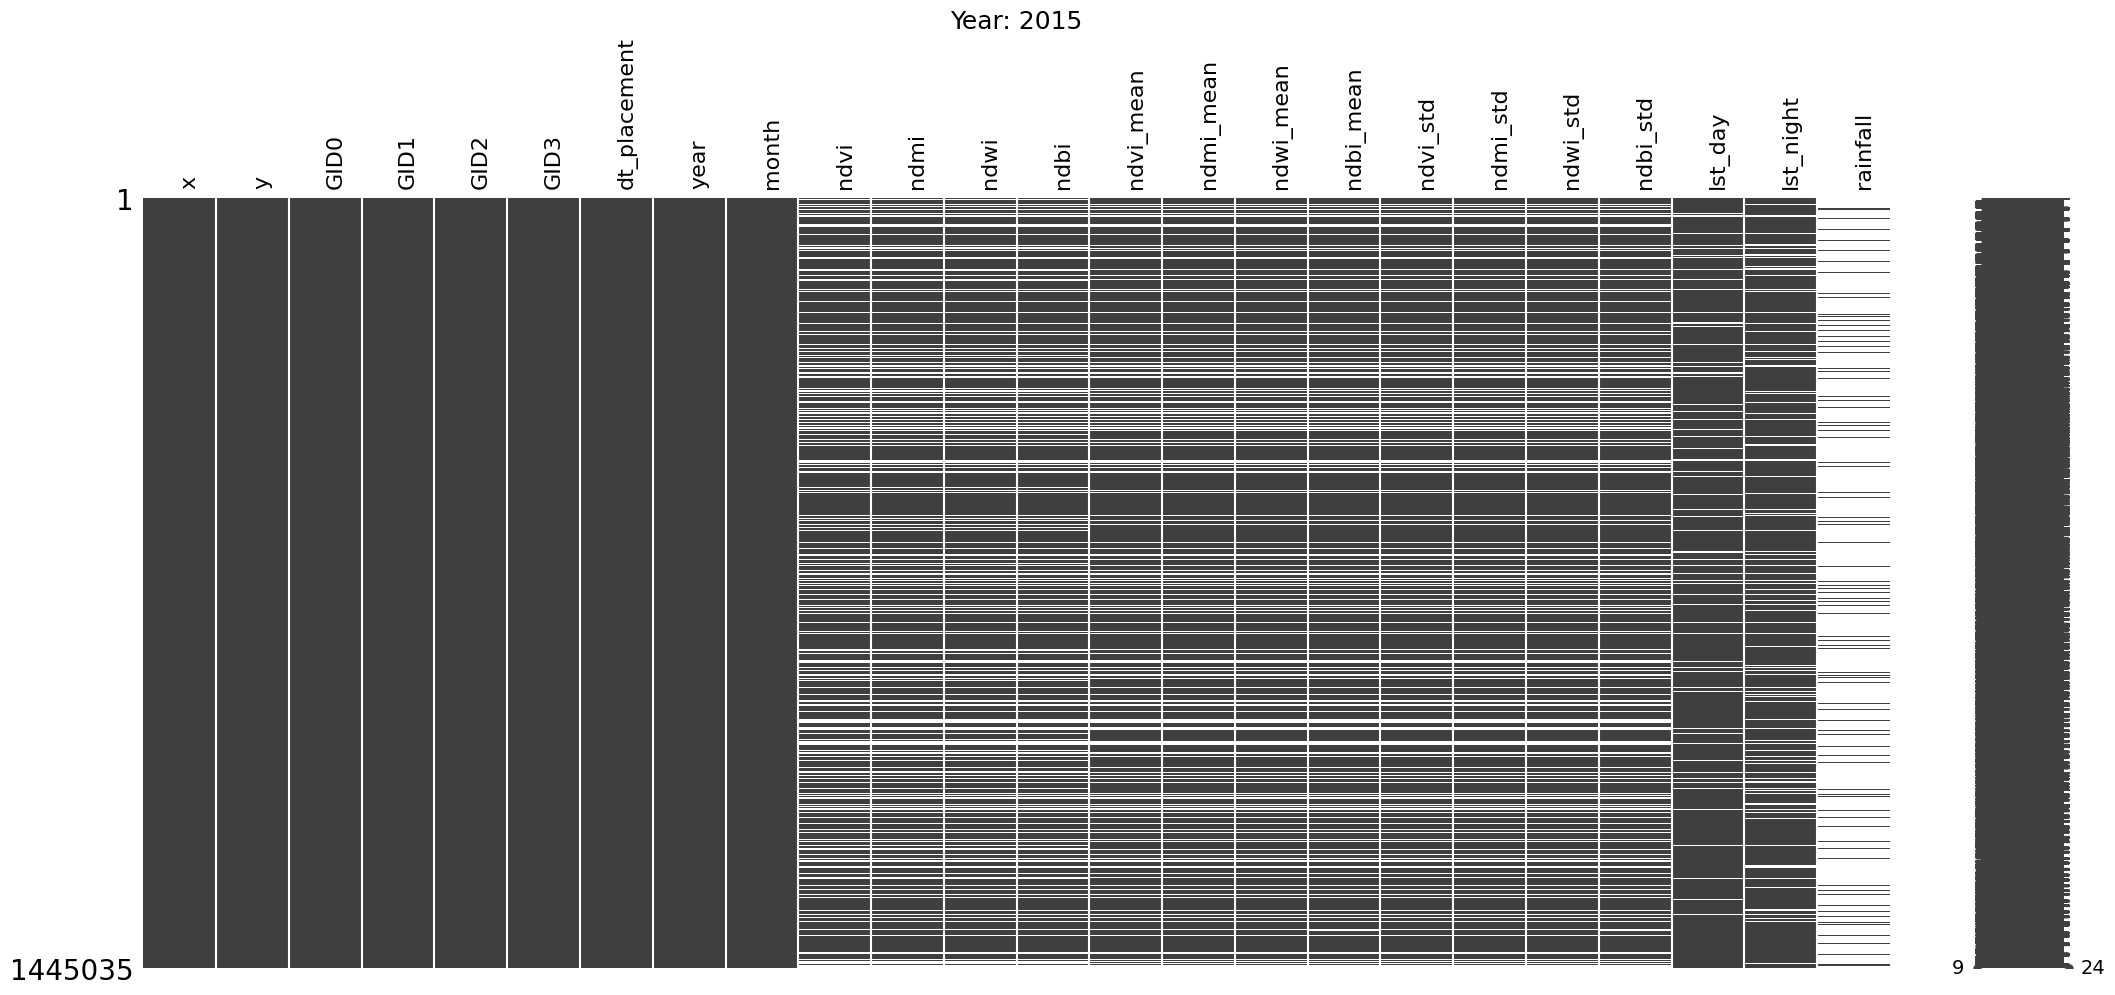

In [318]:
msno.matrix(timeline_file, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {timeline_file.year.iloc[0]}", fontsize=18)

In [319]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2

In [320]:
timeline_file = encode_cyclical(timeline_file, 'month', 12)

In [321]:
timeline_file.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos
0,12.29306,8.21972,nord,faro,poli,balkossa,2015-01-01,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15281.0,14472.0,0.0,14876.5,0.5,0.866
1,12.29306,8.21972,nord,faro,poli,balkossa,2015-01-02,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15219.0,14472.0,0.0,14845.5,0.5,0.866
2,12.29306,8.21972,nord,faro,poli,balkossa,2015-01-03,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15219.0,14472.0,0.0,14845.5,0.5,0.866
3,12.29306,8.21972,nord,faro,poli,balkossa,2015-01-04,2015,1,0.197229,-0.067734,-0.281382,0.067734,0.192376,-0.09172,-0.304954,0.09172,0.01407,0.023051,0.025566,0.023051,15116.0,14328.0,0.0,14722.0,0.5,0.866
4,12.29306,8.21972,nord,faro,poli,balkossa,2015-01-05,2015,1,0.197229,-0.067734,-0.281382,0.067734,0.192376,-0.09172,-0.304954,0.09172,0.01407,0.023051,0.025566,0.023051,15116.0,14328.0,0.0,14722.0,0.5,0.866


In [322]:
geomorphological = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Geomorphological.csv', encoding=enc)
geomorphological.columns = geomorphological.columns.str.lower()
geomorphological.head()

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,13.56021,9.29772,15102.128622,680.892978,2,151.604907,185.418439,180.092206,0.0,1.000000
1,13.59642,9.22586,6838.003488,1865.794331,1,201.794101,197.674022,183.049512,0.0,2.249840
2,13.59642,9.26179,9504.069954,2074.586084,1,136.247919,186.061883,180.318899,0.0,9.050964
3,13.59642,9.29772,12864.041385,781.399397,1,143.777456,188.894941,180.250312,0.0,2.000000
4,13.63262,9.18992,1899.383898,1344.931378,1,151.874866,187.347864,179.798661,0.0,1.000000


In [323]:
geomorphological['x_rounded'] = geomorphological['x'].round(4)
geomorphological['y_rounded'] = geomorphological['y'].round(4)

geomorphological.drop(columns=['x', 'y'], inplace=True)

timeline_file['x_rounded'] = timeline_file['x'].round(4)
timeline_file['y_rounded'] = timeline_file['y'].round(4)

timeline_file = pd.merge(timeline_file, geomorphological, on=['x_rounded', 'y_rounded'], how='left')

timeline_file.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,x_rounded,y_rounded,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,12.29306,8.21972,nord,faro,poli,balkossa,2015-01-01,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15281.0,14472.0,0.0,14876.5,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735
1,12.29306,8.21972,nord,faro,poli,balkossa,2015-01-02,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15219.0,14472.0,0.0,14845.5,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735
2,12.29306,8.21972,nord,faro,poli,balkossa,2015-01-03,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15219.0,14472.0,0.0,14845.5,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735
3,12.29306,8.21972,nord,faro,poli,balkossa,2015-01-04,2015,1,0.197229,-0.067734,-0.281382,0.067734,0.192376,-0.09172,-0.304954,0.09172,0.01407,0.023051,0.025566,0.023051,15116.0,14328.0,0.0,14722.0,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735
4,12.29306,8.21972,nord,faro,poli,balkossa,2015-01-05,2015,1,0.197229,-0.067734,-0.281382,0.067734,0.192376,-0.09172,-0.304954,0.09172,0.01407,0.023051,0.025566,0.023051,15116.0,14328.0,0.0,14722.0,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735


Text(0.5, 1.0, 'Year: 2015')

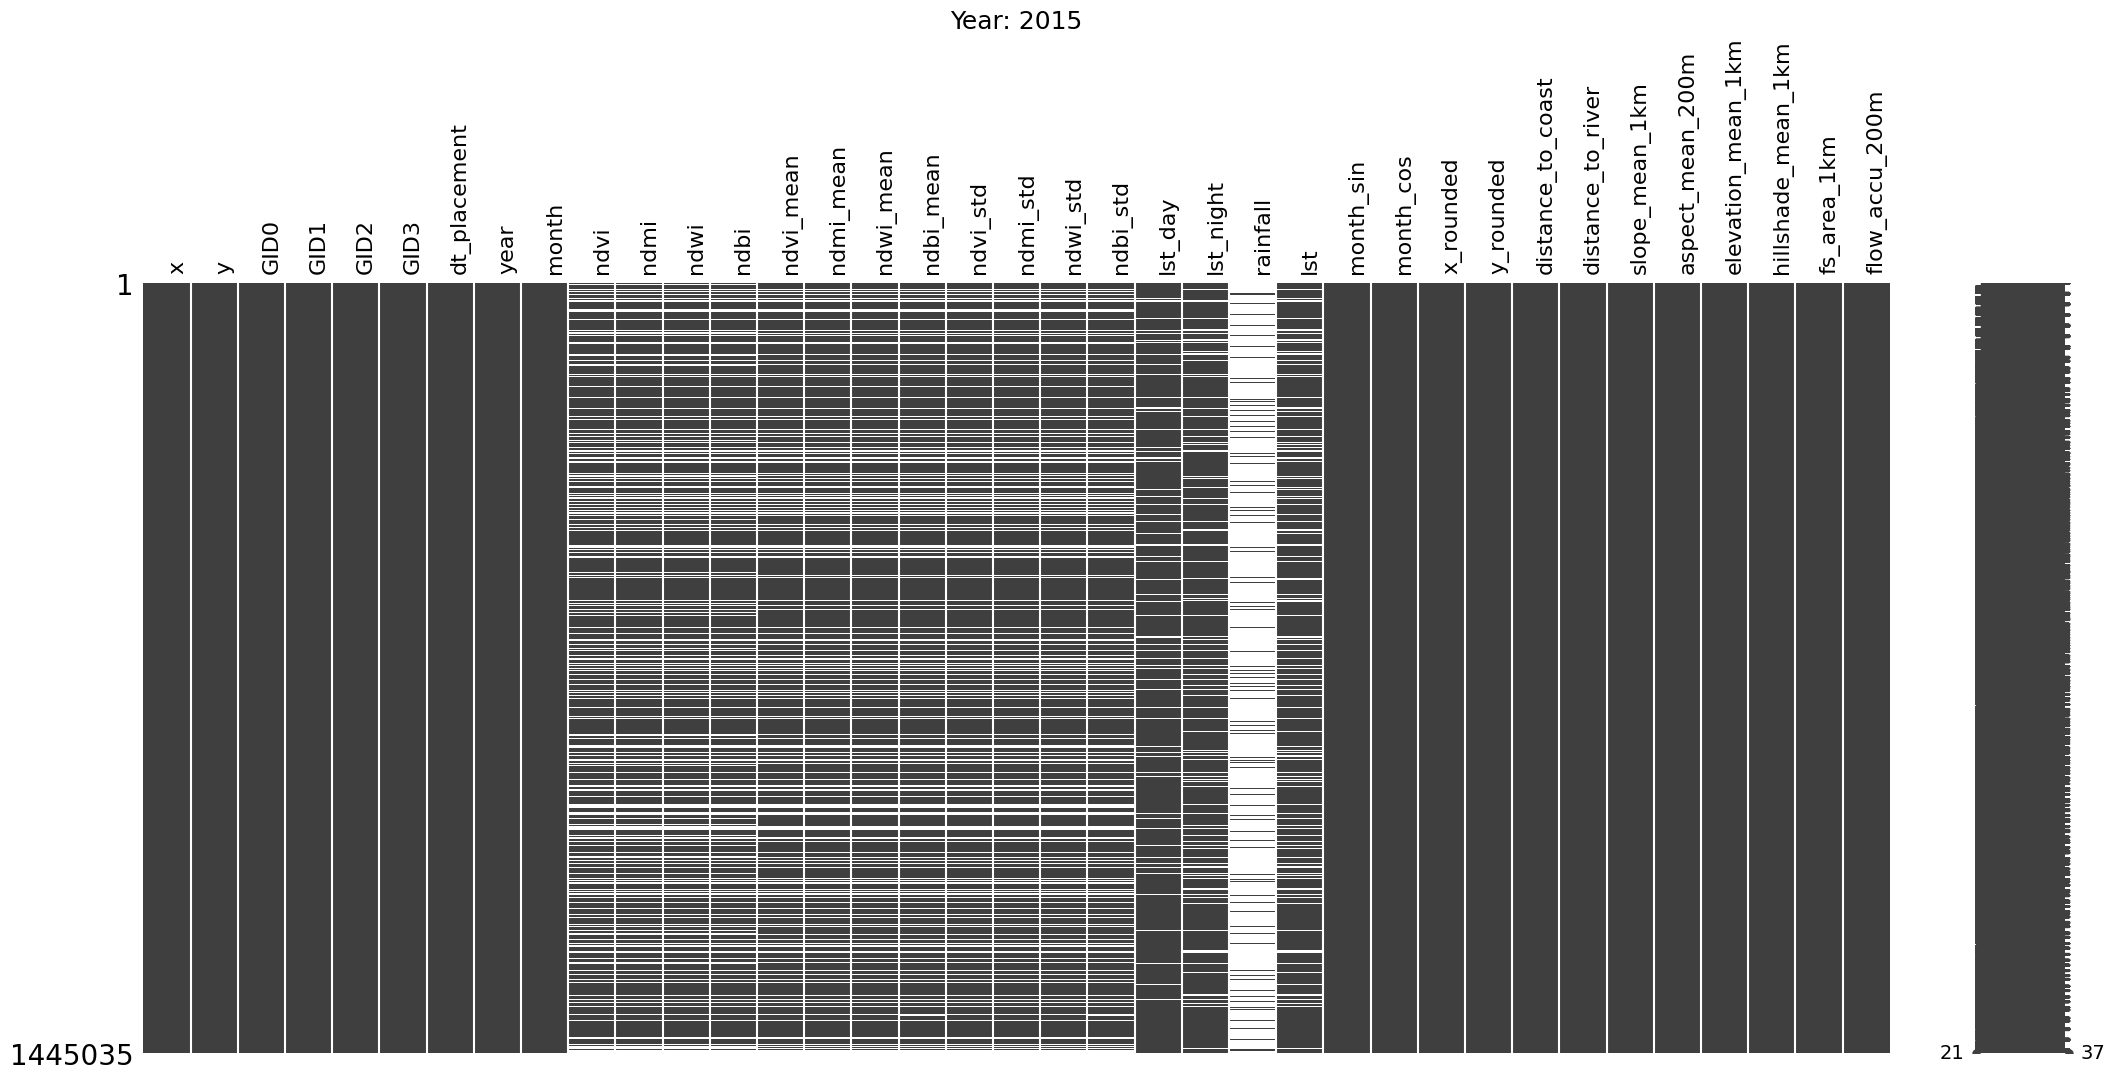

In [324]:
msno.matrix(timeline_file, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {timeline_file.year.iloc[0]}", fontsize=18)

In [325]:
# landcover data of previous year are merged

landcover = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Landcover_2001-2024_processed.csv')
landcover = landcover[landcover['year'] == YEAR - 1].copy()
landcover.head()

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
51467,13.56021,9.29772,2014,31,99,36,99.0,30,99,12,12,1,6,7,2,0
51468,13.59642,9.22586,2014,31,99,36,99.0,30,99,12,12,3,5,8,2,0
51469,13.59642,9.26179,2014,31,99,36,98.0,30,99,12,12,1,6,7,2,0
51470,13.59642,9.29772,2014,31,99,36,98.0,30,99,12,12,1,6,7,2,0
51471,13.63262,9.18992,2014,31,99,36,99.0,30,99,12,12,1,6,7,2,0


In [326]:
landcover['x_rounded'] = landcover['x'].round(4)
landcover['y_rounded'] = landcover['y'].round(4)
landcover.rename(columns={'year': 'year_lc'}, inplace=True)
landcover.drop(columns=['x', 'y'], inplace=True)

timeline_file['year_lc'] = timeline_file['year'] - 1

In [327]:
timeline_file = pd.merge(timeline_file, landcover, on=['x_rounded', 'y_rounded', 'year_lc'], how='left')

timeline_file.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,x_rounded,y_rounded,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,12.29306,8.21972,nord,faro,poli,balkossa,2015-01-01,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15281.0,14472.0,0.0,14876.5,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,2014,31,99,36,96.0,30,99,12,12,3,5,8,2,0
1,12.29306,8.21972,nord,faro,poli,balkossa,2015-01-02,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15219.0,14472.0,0.0,14845.5,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,2014,31,99,36,96.0,30,99,12,12,3,5,8,2,0
2,12.29306,8.21972,nord,faro,poli,balkossa,2015-01-03,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15219.0,14472.0,0.0,14845.5,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,2014,31,99,36,96.0,30,99,12,12,3,5,8,2,0
3,12.29306,8.21972,nord,faro,poli,balkossa,2015-01-04,2015,1,0.197229,-0.067734,-0.281382,0.067734,0.192376,-0.09172,-0.304954,0.09172,0.01407,0.023051,0.025566,0.023051,15116.0,14328.0,0.0,14722.0,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,2014,31,99,36,96.0,30,99,12,12,3,5,8,2,0
4,12.29306,8.21972,nord,faro,poli,balkossa,2015-01-05,2015,1,0.197229,-0.067734,-0.281382,0.067734,0.192376,-0.09172,-0.304954,0.09172,0.01407,0.023051,0.025566,0.023051,15116.0,14328.0,0.0,14722.0,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,2014,31,99,36,96.0,30,99,12,12,3,5,8,2,0


In [328]:
timeline_file.loc[timeline_file['lc_prop1_assessment'] < 80, 'lc_prop1'] = np.nan
timeline_file.loc[timeline_file['lc_prop2_assessment'] < 80, 'lc_prop2'] = np.nan
timeline_file.loc[timeline_file['lc_prop3_assessment'] < 80, 'lc_prop3'] = np.nan

In [329]:
timeline_file.drop(columns=['x_rounded', 'y_rounded', 'lc_prop1_assessment', 'lc_prop2_assessment', 'lc_prop3_assessment', 'lw', 'qc'], inplace=True)

Text(0.5, 1.0, 'Year: 2015')

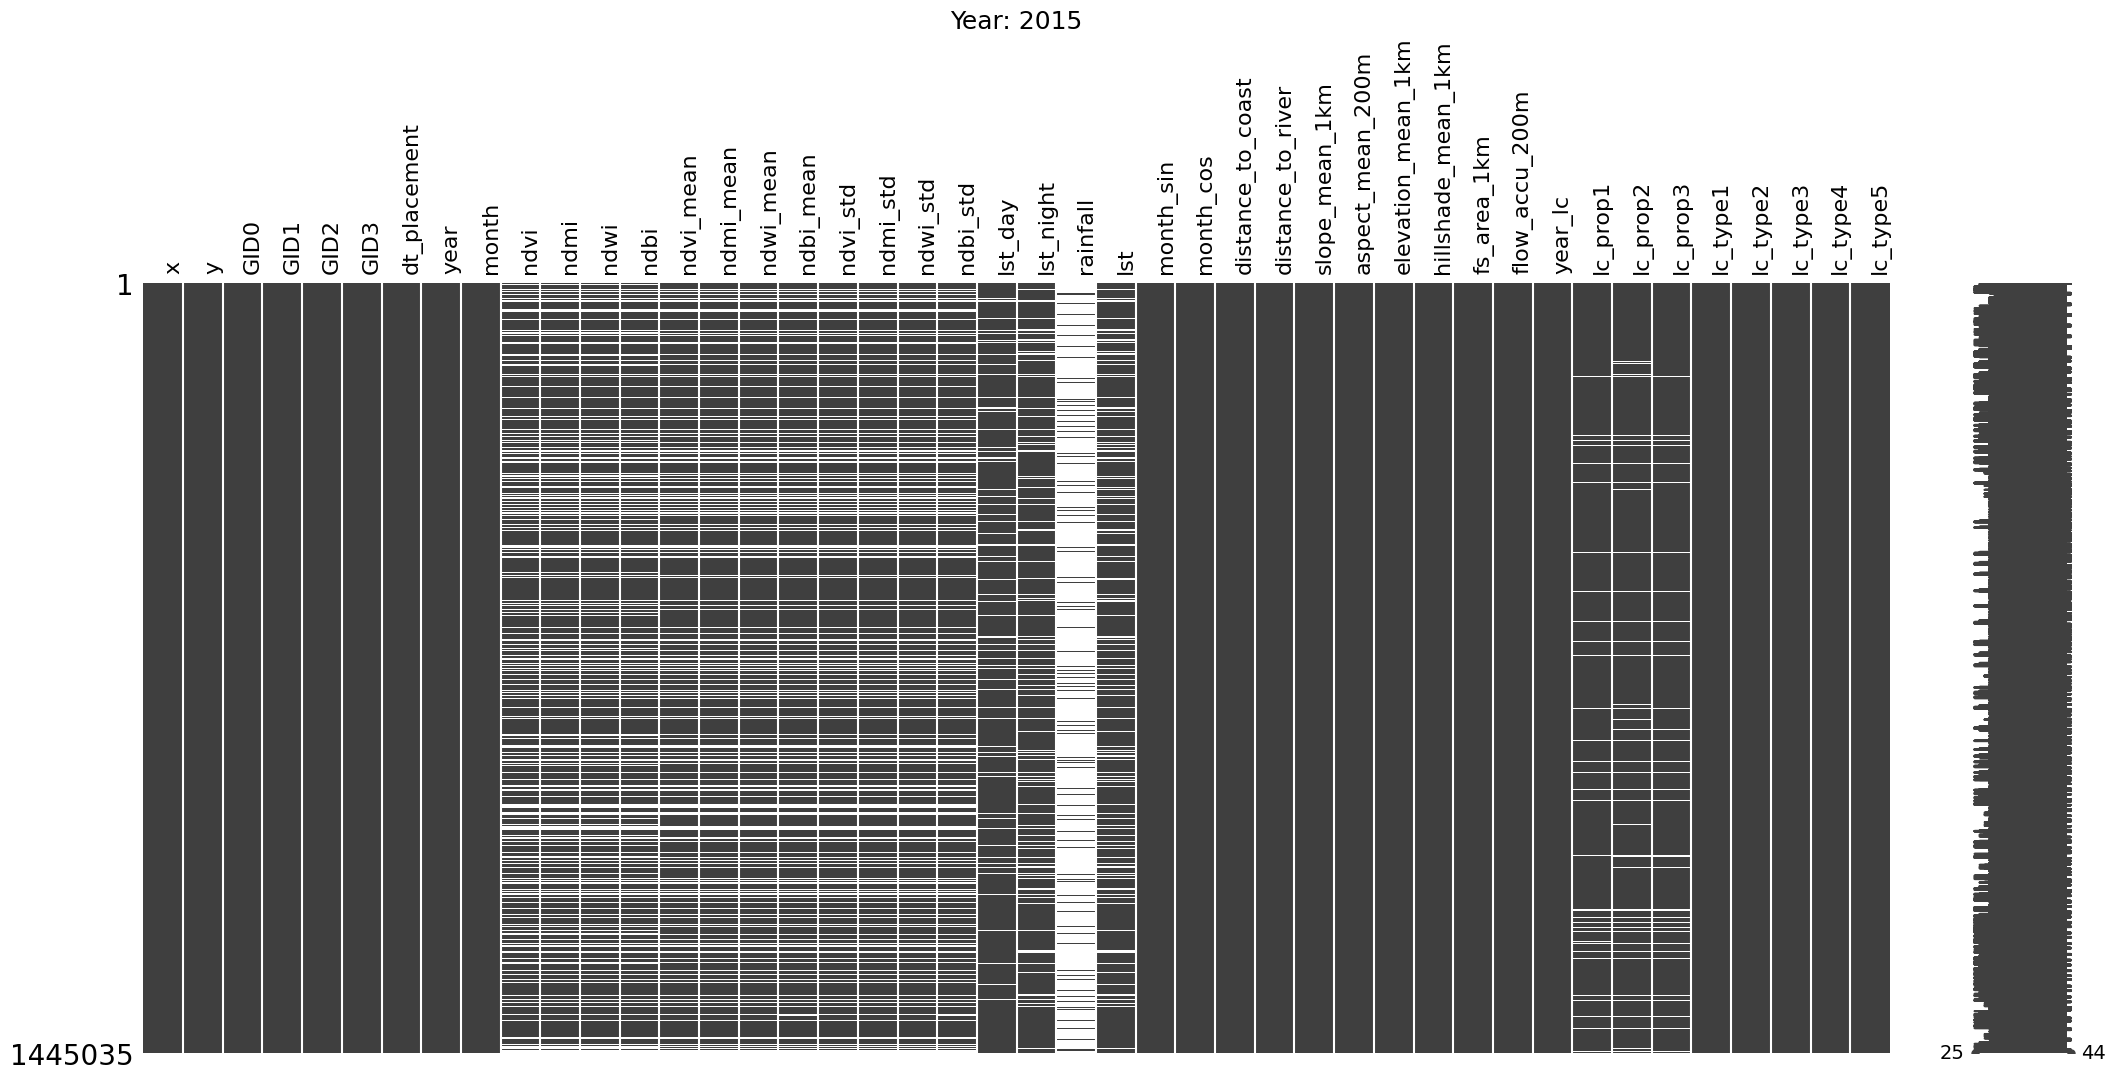

In [330]:
msno.matrix(timeline_file, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {timeline_file.year.iloc[0]}", fontsize=18)

In [331]:
timeline_file

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5
0,12.29306,8.21972,nord,faro,poli,balkossa,2015-01-01,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15281.0,14472.0,0.0,14876.5,0.5,0.866,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,2014,31.0,36.0,30.0,12,12,3,5,8
1,12.29306,8.21972,nord,faro,poli,balkossa,2015-01-02,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15219.0,14472.0,0.0,14845.5,0.5,0.866,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,2014,31.0,36.0,30.0,12,12,3,5,8
2,12.29306,8.21972,nord,faro,poli,balkossa,2015-01-03,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15219.0,14472.0,0.0,14845.5,0.5,0.866,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,2014,31.0,36.0,30.0,12,12,3,5,8
3,12.29306,8.21972,nord,faro,poli,balkossa,2015-01-04,2015,1,0.197229,-0.067734,-0.281382,0.067734,0.192376,-0.091720,-0.304954,0.091720,0.014070,0.023051,0.025566,0.023051,15116.0,14328.0,0.0,14722.0,0.5,0.866,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,2014,31.0,36.0,30.0,12,12,3,5,8
4,12.29306,8.21972,nord,faro,poli,balkossa,2015-01-05,2015,1,0.197229,-0.067734,-0.281382,0.067734,0.192376,-0.091720,-0.304954,0.091720,0.014070,0.023051,0.025566,0.023051,15116.0,14328.0,0.0,14722.0,0.5,0.866,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,2014,31.0,36.0,30.0,12,12,3,5,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1445030,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2015-12-27,2015,12,0.308350,0.023542,-0.262129,-0.023542,0.279483,-0.000009,-0.268913,0.000009,0.028046,0.020370,0.024134,0.020370,15106.0,14411.0,0.0,14758.5,-0.0,1.000,75745.37949,68.862894,3,177.353198,461.652670,179.568663,0.0,3163.658249,2014,22.0,20.0,20.0,9,9,4,4,4
1445031,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2015-12-28,2015,12,0.308350,0.023542,-0.262129,-0.023542,0.279483,-0.000009,-0.268913,0.000009,0.028046,0.020370,0.024134,0.020370,15129.0,14410.0,0.0,14769.5,-0.0,1.000,75745.37949,68.862894,3,177.353198,461.652670,179.568663,0.0,3163.658249,2014,22.0,20.0,20.0,9,9,4,4,4
1445032,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2015-12-29,2015,12,0.308350,0.023542,-0.262129,-0.023542,0.279483,-0.000009,-0.268913,0.000009,0.028046,0.020370,0.024134,0.020370,15078.0,14410.0,0.0,14744.0,-0.0,1.000,75745.37949,68.862894,3,177.353198,461.652670,179.568663,0.0,3163.658249,2014,22.0,20.0,20.0,9,9,4,4,4
1445033,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2015-12-30,2015,12,0.308350,0.023542,-0.262129,-0.023542,0.279483,-0.000009,-0.268913,0.000009,0.028046,0.020370,0.024134,0.020370,15002.0,14387.0,0.0,14694.5,-0.0,1.000,75745.37949,68.862894,3,177.353198,461.652670,179.568663,0.0,3163.658249,2014,22.0,20.0,20.0,9,9,4,4,4


In [332]:
timeline_file.describe()

,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5
count,1.445035e+06,1.445035e+06,1445035.0,1.445035e+06,1.062703e+06,1.062678e+06,1.062703e+06,1.062678e+06,1.104627e+06,1.104577e+06,1.104627e+06,1.104547e+06,1.104627e+06,1.104577e+06,1.104627e+06,1.104547e+06,1.327236e+06,1.261660e+06,146823.000000,1.221048e+06,1.445035e+06,1.445035e+06,1.445035e+06,1.445035e+06,1.445035e+06,1.445035e+06,1.445035e+06,1.445035e+06,1.445035e+06,1.445035e+06,1445035.0,1.389190e+06,1.371670e+06,1.383715e+06,1.445035e+06,1.445035e+06,1.445035e+06,1.445035e+06,1.445035e+06
mean,1.394363e+01,8.485321e+00,2015.0,6.526027e+00,3.615209e-01,5.613923e-02,-3.022501e-01,-5.613923e-02,3.609879e-01,6.113282e-02,-2.958377e-01,-6.113266e-02,2.398006e-02,2.159666e-02,2.046768e-02,2.159657e-02,1.532121e+04,1.468083e+04,0.055638,1.500404e+04,-5.380822e-03,-2.372603e-03,7.263910e+04,1.430515e+03,4.528669e+00,1.618835e+02,4.953245e+02,1.799451e+02,2.239887e-02,7.795053e+02,2014.0,2.674356e+01,2.783023e+01,2.536376e+01,1.041526e+01,1.017934e+01,3.096742e+00,4.577419e+00,5.647133e+00
std,7.548784e-01,7.046535e-01,0.0,3.447853e+00,1.797425e-01,1.589343e-01,1.132115e-01,1.589343e-01,1.749925e-01,1.571070e-01,1.108723e-01,1.571084e-01,2.523962e-02,1.656578e-02,2.504936e-02,1.656583e-02,3.049630e+02,1.658689e+02,0.530236,1.962053e+02,7.056218e-01,7.085441e-01,4.473122e+04,9.846611e+02,5.704843e+00,4.624303e+01,2.652512e+02,5.401438e+00,2.377980e-01,9.470593e+03,0.0,5.039669e+00,7.799746e+00,5.539372e+00,1.724914e+00,1.791668e+00,1.210582e+00,1.072754e+00,2.031456e+00
min,1.229306e+01,7.069850e+00,2015.0,1.000000e+00,-5.338524e-01,-5.199654e-01,-5.702316e-01,-8.890417e-01,-5.312390e-01,-2.543050e-01,-5.559947e-01,-8.210279e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.334100e+04,1.384000e+04,0.000000,1.406000e+04,-1.000000e+00,-1.000000e+00,1.660909e+01,5.129964e-04,0.000000e+00,0.000000e+00,1.691704e+02,1.196138e+02,0.000000e+00,1.000000e+00,2014.0,3.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.334299e+01,7.968190e+00,2015.0,4.000000e+00,2.127644e-01,-8.054785e-02,-3.718990e-01,-1.924113e-01,2.144060e-01,-7.531442e-02,-3.662643e-01,-1.987816e-01,1.021011e-02,1.090013e-02,9.082028e-03,1.090013e-02,1.509700e+04,1.457400e+04,0.000000,1.486400e+04,-8.660000e-01,-8.660000e-01,3.328515e+04,6.102712e+02,2.000000e+00,1.315493e+02,3.082905e+02,1.785421e+02,0.000000e+00,1.224904e+00,2014.0,2.200000e+01,2.000000e+01,2.000000e+01,9.000000e+00,9.000000e+00,3.000000e+00,4.000000e+00,4.000000e+00
50%,1.392226e+01,8.399390e+00,2015.0,7.000000e+00,3.315844e-01,2.291228e-02,-3.173112e-01,-2.291228e-02,3.353735e-01,2.948852e-02,-3.103836e-01,-2.948691e-02,1.699051e-02,1.759800e-02,1.411981e-02,1.759800e-02,1.526300e+04,1.470300e+04,0.000000,1.498250e+04,0.000000e+00,0.000000e+00,7.134045e+04,1.266644e+03,3.000000e+00,1.616719e+02,4.114362e+02,1.800481e+02,0.000000e+00,2.444942e+00,2014.0,3.100000e+01,3.000000e+01,3.000000e+01,1.000000e+01,1.000000e+01,3.000000e+00,5.000000e+00,6.000000e+00
75%,1.453774e+01,8.974320e+00,2015.0,1.000000e+01,5.198827e-01,1.924113e-01,-2.525937e-01,8.054785e-02,5.150919e-01,1.987779e-01,-2.442051e-01,7.531704e-02,2.813313e-02,2.773446e-02,2.303912e-02,2.773446e-02,1.552000e+04,1.479600e+04,0.000000,1.513300e+04,5.000000e-01,8.660000e-01,1.055138e+05,2.112235e+03,5.000000e+00,1.920474e+02,6.036195e+02,1.815590e+02,0.000000e+00,8.774023e+00,2014.0,3.100000e+01,3.600000e+01,3.000000e+01,1.200000e+01,1.200000e+01,4.000000e+00,5.000000e+00,8.000000e+00
max,1.555146e+01,1.023199e+01,2015.0,1.200000e+01,7.895542e-01,8.890417e-01,9.219484e-01,5.199654e-01,7.726399e-01,8.2102

In [333]:
gid_unit_counts = []

for gid_unit in timeline_file.GID3.sort_values().unique().tolist():
    count = (timeline_file['GID3'] == gid_unit).sum()
    gid_unit_counts.append({'GID3': gid_unit,
                            'count': count})

gid_unit_counts_df = pd.DataFrame(gid_unit_counts)

In [334]:
gid_unit_counts_df.head()

,GID3,count
0,adoumri,1825
1,alpha,24820
2,babla,2920
3,babouri,1460
4,badadji,1095


In [335]:
gid_unit_counts_df.describe()

,count
count,144.000000
mean,10034.965278
std,16686.863793
min,365.000000
25%,1825.000000
50%,4015.000000
75%,10311.250000
max,127385.000000


In [336]:
fig = px.bar(gid_unit_counts_df, x='GID3', y='count', title='Count per Region')
fig.update_layout(xaxis_title='Region (GID3)', yaxis_title='Count')
fig.show()

In [337]:
group_cols = ['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3']
mode_cols = ['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5']
geo_cols = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m']

grouped_by_gid3 = timeline_file.groupby(group_cols, as_index = False)

grouped_by_gid3_mean = grouped_by_gid3.mean()
grouped_by_gid3_std = grouped_by_gid3.std()

grouped_by_gid3_most_common = timeline_file[group_cols].drop_duplicates()

for col in mode_cols:
    mode_series = (timeline_file.groupby(group_cols)[col].value_counts().groupby(level=group_cols).idxmax().apply(lambda x: x[-1]).reset_index(name=col))
    grouped_by_gid3_most_common = grouped_by_gid3_most_common.merge(mode_series, on=group_cols, how='left')


In [338]:
grouped_by_gid3_mean.drop(columns = mode_cols, inplace=True)
grouped_by_gid3_std = grouped_by_gid3_std[group_cols + geo_cols].copy()
grouped_by_gid3_std.columns = group_cols + [f"{col}_std" for col in geo_cols]

In [339]:
grouped_by_gid3 = grouped_by_gid3_mean.merge(grouped_by_gid3_std, on=group_cols, how='left')
grouped_by_gid3 = grouped_by_gid3.merge(grouped_by_gid3_most_common, on=group_cols, how='left')

In [340]:
print(f'Shape of the grouped_by_gid3 file: {grouped_by_gid3.shape}')

Shape of the grouped_by_gid3 file: (52925, 52)


Text(0.5, 1.0, 'Year: 2015.0')

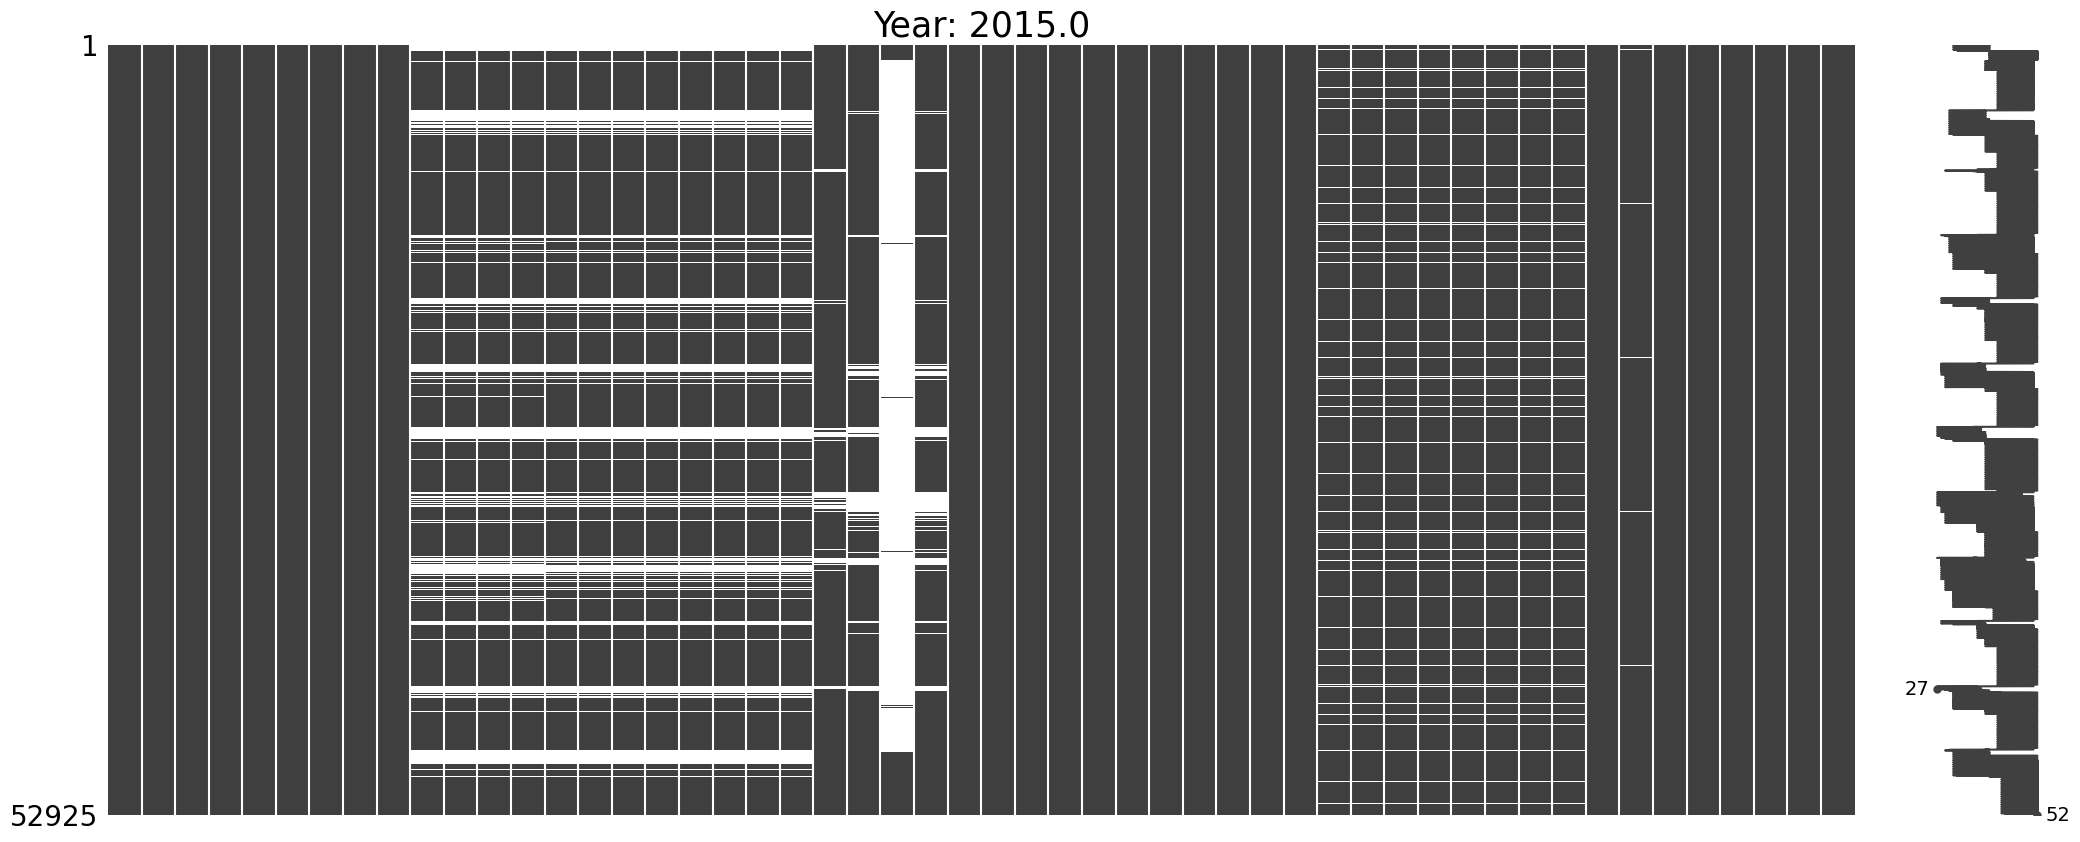

In [341]:
msno.matrix(grouped_by_gid3, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {grouped_by_gid3.year.iloc[0]}", fontsize=25)

In [342]:
gid_mean_unit_counts = []

for gid_unit in grouped_by_gid3.GID3.sort_values().unique().tolist():
    count = (grouped_by_gid3['GID3'] == gid_unit).sum()
    gid_mean_unit_counts.append({'GID3': gid_unit,
                            'count': count})

gid_mean_unit_counts_df = pd.DataFrame(gid_mean_unit_counts)

In [343]:
fig = px.bar(gid_mean_unit_counts_df, x='GID3', y='count', title='Count per Region')
fig.update_layout(xaxis_title='Region (GID3)', yaxis_title='Count')
fig.show()

In [344]:
grouped_by_gid3 = convert_temperature(grouped_by_gid3)

In [345]:
grouped_by_gid3.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5
0,2015-01-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2015.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.178000,18.242000,0.0,27.210000,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2014.0,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12,12,3,5,8
1,2015-01-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2015.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.321282,19.125897,0.0,27.223590,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,2014.0,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12,12,3,5,8
2,2015-01-01,nord,benoue,bibemi,bide,13.972945,9.422292,2015.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.812667,19.547333,0.0,27.180000,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,2014.0,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12,12,3,5,8
3,2015-01-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2015.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.440909,17.297273,0.0,26.369091,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,2014.0,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12,12,1,6,7
4,2015-01-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2015.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.983333,20.110000,0.0,27.546667,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,2014.0,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12,12,3,5,8


In [346]:
grouped_by_gid3['year'] = grouped_by_gid3['year'].astype(int)
grouped_by_gid3['year_lc'] = grouped_by_gid3['year_lc'].astype(int)
grouped_by_gid3['month'] = grouped_by_gid3['month'].astype(int)

In [347]:
grouped_by_gid3.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5
0,2015-01-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.178000,18.242000,0.0,27.210000,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2014,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12,12,3,5,8
1,2015-01-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.321282,19.125897,0.0,27.223590,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,2014,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12,12,3,5,8
2,2015-01-01,nord,benoue,bibemi,bide,13.972945,9.422292,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.812667,19.547333,0.0,27.180000,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,2014,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12,12,3,5,8
3,2015-01-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.440909,17.297273,0.0,26.369091,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,2014,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12,12,1,6,7
4,2015-01-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.983333,20.110000,0.0,27.546667,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,2014,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12,12,3,5,8


Text(0.5, 1.0, 'Year: 2015')

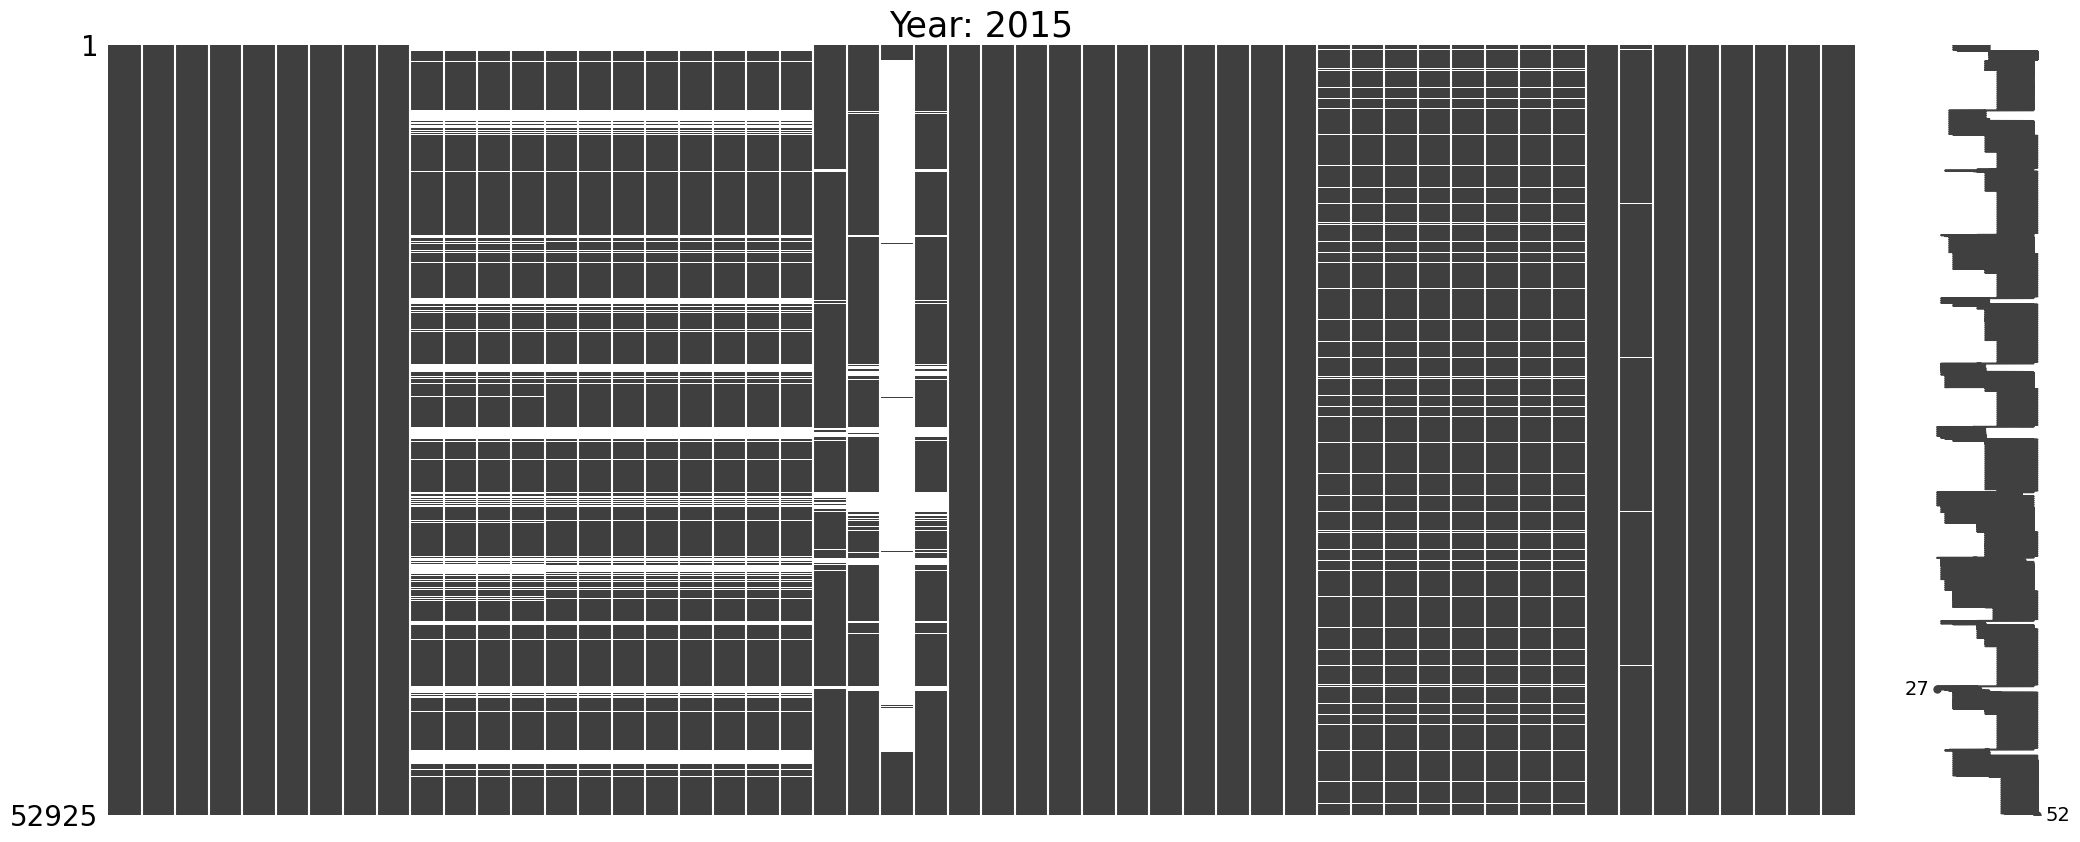

In [348]:
msno.matrix(grouped_by_gid3, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {grouped_by_gid3.year.iloc[0]}", fontsize=25)

In [349]:
grouped_by_gid3.describe()

,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5
count,52925.000000,52925.000000,52925.0,52925.000000,43586.000000,43578.000000,43586.000000,43578.000000,44226.000000,44223.000000,44226.000000,44223.000000,44226.000000,44223.000000,44226.000000,44223.000000,50291.000000,48672.000000,5705.000000,47868.000000,52925.000000,52925.000000,52925.000000,52925.000000,52925.000000,52925.000000,52925.000000,52925.000000,52925.000000,52925.000000,52925.0,49640.000000,49640.000000,49640.000000,49640.000000,49640.000000,49640.000000,49640.000000,49640.000000,52925.000000,52560.000000,52925.000000,52925.000000,52925.000000,52925.000000,52925.000000,52925.000000
mean,13.774721,9.158610,2015.0,6.526027,0.316986,0.010326,-0.323276,-0.010326,0.314110,0.012331,-0.318462,-0.012330,0.023981,0.022101,0.020834,0.022101,35.079898,21.393082,0.044609,28.278003,-0.005381,-0.002373,41654.661825,1428.029921,3.729529,159.308885,376.388821,179.630904,0.024979,1094.054790,2014.0,5837.697758,934.910824,3.658201,37.898242,69.615188,3.553276,0.052659,3787.105701,29.944828,32.805556,28.827586,11.531034,11.531034,2.958621,5.062069,7.289655
std,0.567528,0.678537,0.0,3.447884,0.157104,0.142180,0.089313,0.142180,0.153325,0.141183,0.086937,0.141183,0.018511,0.015334,0.020238,0.015334,5.574144,3.032749,0.314323,3.620826,0.705628,0.708551,32583.262349,459.633657,2.224654,18.925192,167.384008,1.731779,0.121316,3664.311966,0.0,4226.712351,284.768515,2.989741,15.141191,72.235383,4.021164,0.227847,10988.842890,2.895397,6.769356,3.217107,1.083142,1.083142,1.333279,0.666657,1.389219
min,12.383569,7.276898,2015.0,1.000000,-0.099471,-0.225361,-0.496606,-0.679062,-0.159597,-0.226935,-0.503750,-0.678856,0.000000,0.000000,0.000000,0.000000,16.570000,10.426250,0.000000,16.220000,-1.000000,-1.000000,2107.273950,142.990406,0.666667,84.672313,179.122926,172.180250,0.000000,1.129111,2014.0,109.196799,189.666077,0.500000,1.854461,2.333805,0.041012,0.000000,0.134126,22.000000,9.000000,20.000000,9.000000,9.000000,1.000000,4.000000,4.000000
25%,13.440741,8.789951,2015.0,4.000000,0.187284,-0.107583,-0.383010,-0.127065,0.187835,-0.105182,-0.379884,-0.129604,0.011223,0.012213,0.011667,0.012213,30.934800,19.492810,0.000000,25.716250,-0.866000,-0.866000,18537.260762,1218.217279,2.220588,150.782168,248.536063,179.145577,0.000000,7.056847,2014.0,3334.200586,783.651628,1.477368,27.804608,21.719200,1.263409,0.000000,14.011861,31.000000,36.000000,30.000000,12.000000,12.000000,3.000000,5.000000,7.000000
50%,13.707817,9.286943,2015.0,7.000000,0.267486,-0.036596,-0.337146,0.036596,0.268063,-0.032268,-0.332846,0.032268,0.019512,0.019701,0.015683,0.019701,34.193500,21.767500,0.000000,27.970000,0.000000,0.000000,29895.396877,1450.222681,3.055556,162.545910,331.761974,180.046801,0.000000,42.730502,2014.0,4500.068289,975.250678,2.444583,39.063645,40.891866,2.122457,0.000000,135.277674,31.000000,36.000000,30.000000,12.000000,12.000000,3.000000,5.000000,8.000000
75%,13.994668,9.696256,2015.0,10.000000,0.452008,0.127065,-0.282231,0.107583,0.445565,0.129604,-0.273000,0.105182,0.030584,0.028512,0.023133,0.028512,39.080667,23.570000,0.000000,30.746667,0.500000,0.866000,57865.678799,1616.602077,4.625000,169.274173,448.096953,180.577534,0.000000,379.689941,2014.0,6828.521411,1082.475494,5.279347,47.689146,90.134013,4.253803,0.000000,1666.470062,31.000000,36.000000,30.000000,12.000000,12.000000,3.000000,5.000000,8.000000
max,15.461737,10.196057,2015.0,12.000000,0.692703,0.679062,0.686996,0.225361,0.687118,0.678856,0.472296,0.226935,0

In [350]:
# Group by the needed dimensions
grouped_mask = grouped_by_gid3.groupby(['GID2', 'GID3', 'year', 'month'])

# Compute the min and max temperature across lst_day and lst_night
monthly_lst_min = grouped_mask[['lst_day', 'lst_night']].min().min(axis=1)
monthly_lst_max = grouped_mask[['lst_day', 'lst_night']].max().max(axis=1)

# Compute total precipitation
monthly_rainfall_acc = grouped_mask['rainfall'].sum()

# Combine results into a single DataFrame
min_max_acc_weather_df = pd.DataFrame({
    'monthly_lst_min': monthly_lst_min,
    'monthly_lst_max': monthly_lst_max,
    'monthly_rainfall_acc': monthly_rainfall_acc
}).reset_index()

In [351]:
min_max_acc_weather_df

,GID2,GID3,year,month,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,bibemi,adoumri,2015,1,12.742000,43.686000,0.000000
1,bibemi,adoumri,2015,2,17.502000,46.254000,0.000000
2,bibemi,adoumri,2015,3,18.090000,47.822000,0.000000
3,bibemi,adoumri,2015,4,19.782000,52.346000,0.000000
4,bibemi,adoumri,2015,5,20.758000,45.714000,0.000000
...,...,...,...,...,...,...,...
1735,touboro,yanli,2015,8,15.070000,30.159677,0.000000
1736,touboro,yanli,2015,9,20.001724,32.403548,0.000000
1737,touboro,yanli,2015,10,20.540323,32.055161,0.000000
1738,touboro,yanli,2015,11,15.224194,35.485484,0.000000


In [352]:
dataset = pd.merge(grouped_by_gid3, min_max_acc_weather_df, on=['GID2', 'GID3', 'year', 'month'], how='left')

In [353]:
dataset.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2015-01-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.178000,18.242000,0.0,27.210000,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2014,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12,12,3,5,8,12.742000,43.686000,0.0
1,2015-01-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.321282,19.125897,0.0,27.223590,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,2014,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12,12,3,5,8,13.344359,43.412051,0.0
2,2015-01-01,nord,benoue,bibemi,bide,13.972945,9.422292,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.812667,19.547333,0.0,27.180000,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,2014,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12,12,3,5,8,13.283333,43.788667,0.0
3,2015-01-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.440909,17.297273,0.0,26.369091,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,2014,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12,12,1,6,7,12.311818,41.768182,0.0
4,2015-01-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.983333,20.110000,0.0,27.546667,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,2014,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12,12,3,5,8,12.650000,42.270000,0.0


Text(0.5, 1.0, 'Year: 2015')

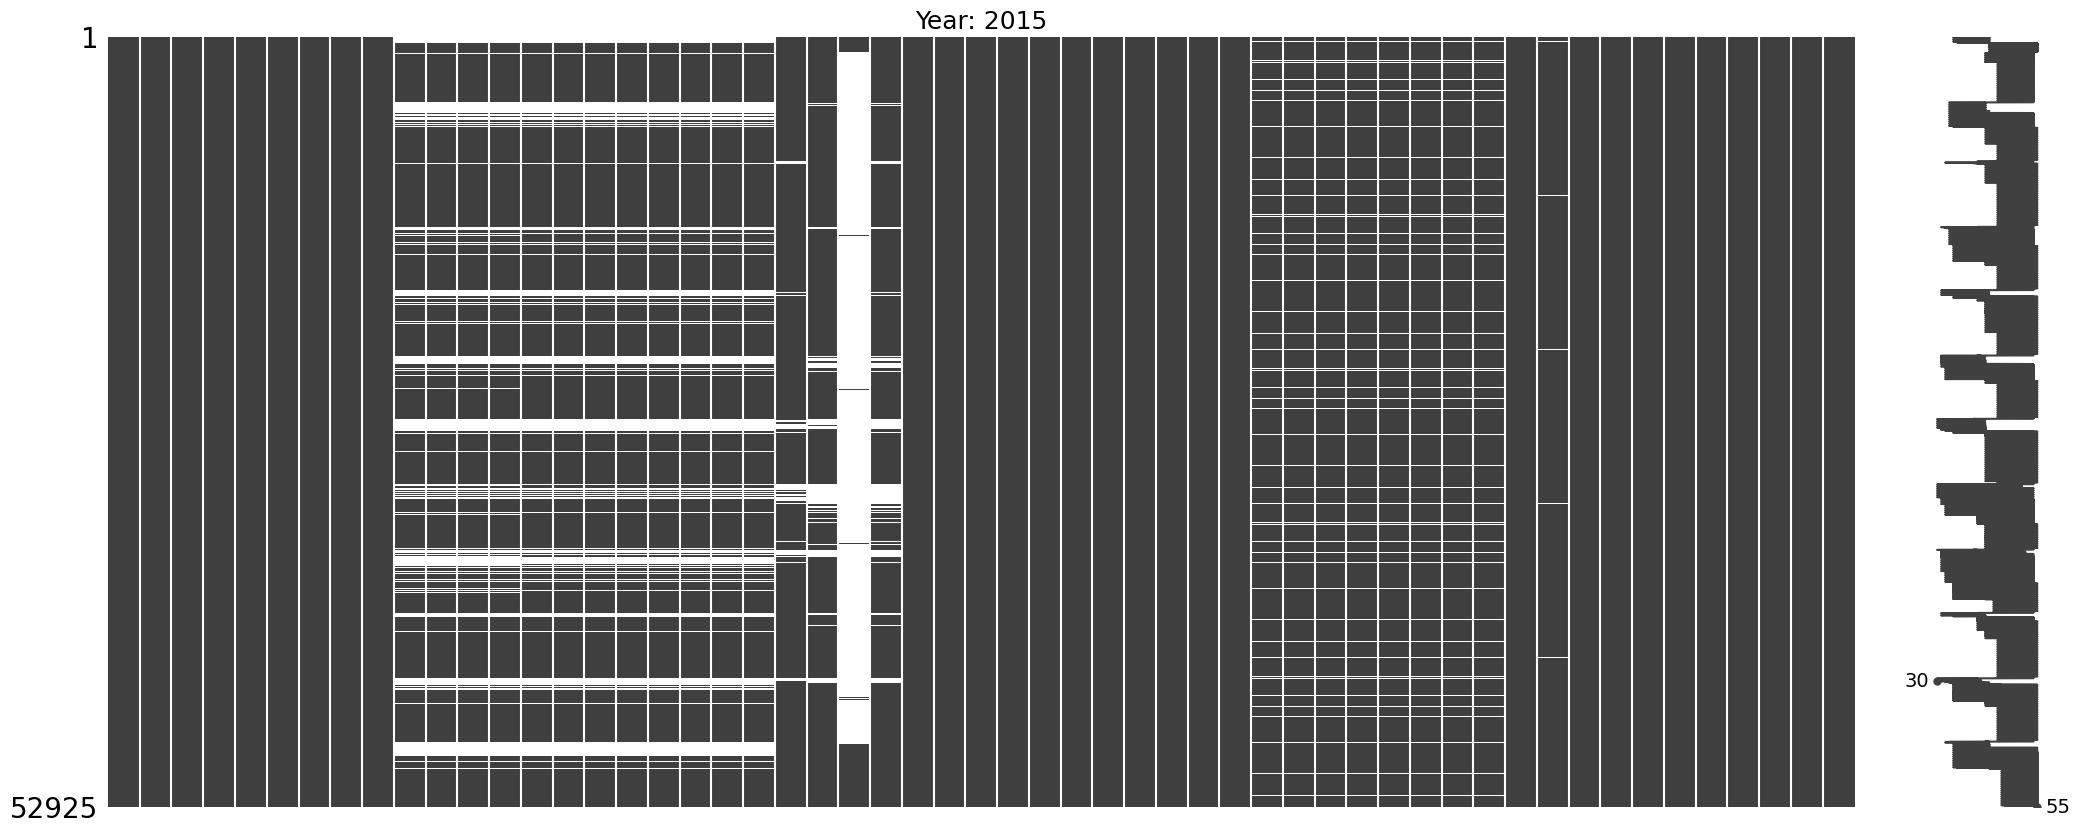

In [354]:
msno.matrix(dataset, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {dataset.year.iloc[0]}", fontsize=18)

In [355]:
dataset.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)
dataset['date_string'] = dataset['month'].astype(str) + '-' + dataset['year'].astype(str)
dataset['dt_placement'] = pd.to_datetime(dataset['date_string'], format='%m-%Y').dt.to_period('M')
dataset.drop(columns=['date_string'], inplace = True)

In [356]:
dataset.head()

,dt_placement_daily,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,dt_placement
0,2015-01-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.178000,18.242000,0.0,27.210000,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2014,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12,12,3,5,8,12.742000,43.686000,0.0,2015-01
1,2015-01-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.321282,19.125897,0.0,27.223590,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,2014,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12,12,3,5,8,13.344359,43.412051,0.0,2015-01
2,2015-01-01,nord,benoue,bibemi,bide,13.972945,9.422292,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.812667,19.547333,0.0,27.180000,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,2014,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12,12,3,5,8,13.283333,43.788667,0.0,2015-01
3,2015-01-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.440909,17.297273,0.0,26.369091,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,2014,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12,12,1,6,7,12.311818,41.768182,0.0,2015-01
4,2015-01-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.983333,20.110000,0.0,27.546667,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,2014,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12,12,3,5,8,12.650000,42.270000,0.0,2015-01


In [357]:
grouped_by_month = dataset.drop(columns=['dt_placement_daily']).groupby(['dt_placement','GID0','GID1','GID2','GID3'], as_index = False)

In [358]:
grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_sum = grouped_by_month.sum()

In [359]:
grouped_by_month_mean.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2015-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2015.0,1.0,0.160002,-0.120537,-0.342115,0.120537,0.164934,-0.117264,-0.346438,0.117264,0.008212,0.013665,0.015085,0.013665,35.562516,16.757355,0.0,26.159935,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2014.0,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,12.742000,43.686000,0.0
1,2015-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2015.0,1.0,0.180811,-0.103038,-0.337729,0.103038,0.180456,-0.102711,-0.336806,0.102711,0.010560,0.011225,0.011200,0.011225,35.182870,17.700885,0.0,26.441878,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,2014.0,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,13.344359,43.412051,0.0
2,2015-01,nord,benoue,bibemi,bide,13.972945,9.422292,2015.0,1.0,0.172986,-0.089423,-0.323776,0.089423,0.177404,-0.085450,-0.325494,0.085450,0.008799,0.009392,0.009824,0.009392,35.349226,17.832065,0.0,26.590645,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,2014.0,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,13.283333,43.788667,0.0
3,2015-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2015.0,1.0,0.178563,-0.067295,-0.292543,0.067295,0.180811,-0.066269,-0.294958,0.066269,0.012477,0.018840,0.018732,0.018840,33.780850,16.095806,0.0,24.938328,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,2014.0,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,12.311818,41.768182,0.0
4,2015-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2015.0,1.0,0.181085,-0.013806,-0.254480,0.013806,0.183872,-0.008080,-0.256086,0.008080,0.023456,0.022051,0.047988,0.022051,34.226989,18.423548,0.0,26.325269,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,2014.0,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,12.650000,42.270000,0.0


In [360]:
print(f'Shape of the grouped_by_month_mean file: {grouped_by_month_mean.shape}')

Shape of the grouped_by_month_mean file: (1740, 55)


Text(0.5, 1.0, 'Year: 2015.0')

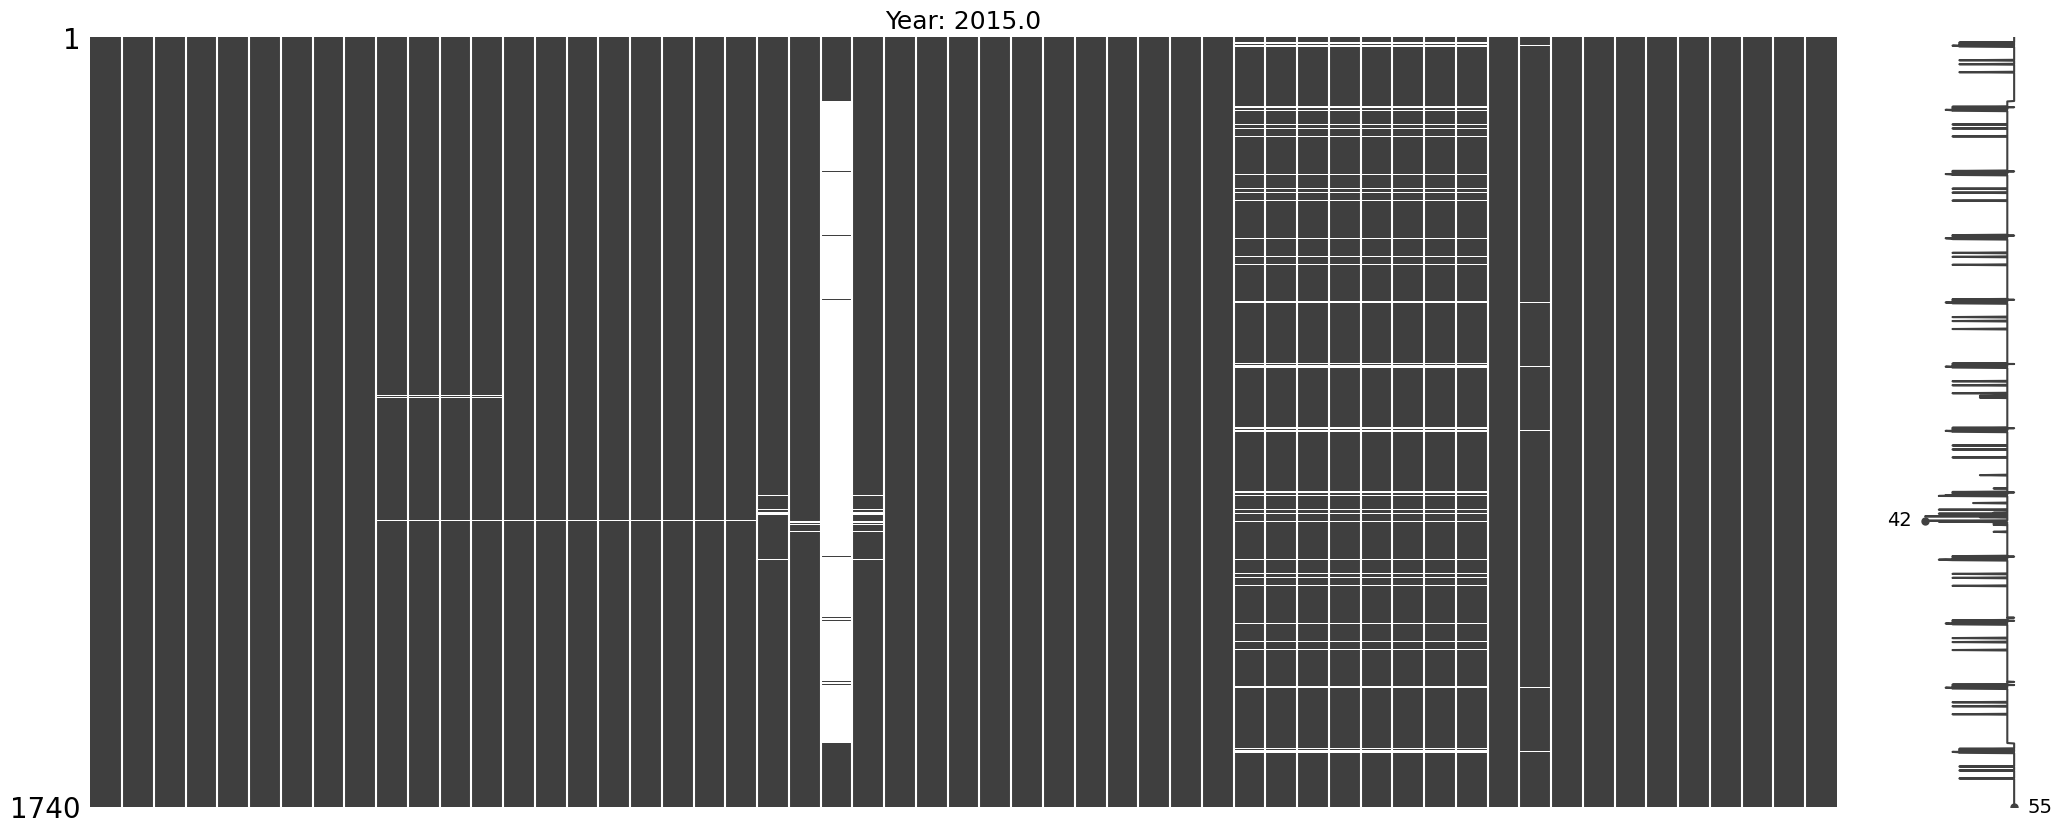

In [361]:
msno.matrix(grouped_by_month_mean, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {grouped_by_month_mean.year.iloc[0]}", fontsize=18)

In [362]:
grouped_by_month_mean

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2015-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2015.0,1.0,0.160002,-0.120537,-0.342115,0.120537,0.164934,-0.117264,-0.346438,0.117264,0.008212,0.013665,0.015085,0.013665,35.562516,16.757355,0.000000,26.159935,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2014.0,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,12.742000,43.686000,0.000000
1,2015-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2015.0,1.0,0.180811,-0.103038,-0.337729,0.103038,0.180456,-0.102711,-0.336806,0.102711,0.010560,0.011225,0.011200,0.011225,35.182870,17.700885,0.000000,26.441878,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,2014.0,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,13.344359,43.412051,0.000000
2,2015-01,nord,benoue,bibemi,bide,13.972945,9.422292,2015.0,1.0,0.172986,-0.089423,-0.323776,0.089423,0.177404,-0.085450,-0.325494,0.085450,0.008799,0.009392,0.009824,0.009392,35.349226,17.832065,0.000000,26.590645,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,2014.0,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,13.283333,43.788667,0.000000
3,2015-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2015.0,1.0,0.178563,-0.067295,-0.292543,0.067295,0.180811,-0.066269,-0.294958,0.066269,0.012477,0.018840,0.018732,0.018840,33.780850,16.095806,0.000000,24.938328,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,2014.0,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,12.311818,41.768182,0.000000
4,2015-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2015.0,1.0,0.181085,-0.013806,-0.254480,0.013806,0.183872,-0.008080,-0.256086,0.008080,0.023456,0.022051,0.047988,0.022051,34.226989,18.423548,0.000000,26.325269,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,2014.0,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,12.650000,42.270000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1735,2015-12,nord,mayo-rey,touboro,mbeing,15.001895,7.650008,2015.0,12.0,0.392715,0.029079,-0.340829,-0.029079,0.392909,0.030422,-0.341234,-0.030416,0.021417,0.026589,0.016939,0.026586,27.336132,15.559308,0.010054,21.447720,0.0,1.000,125988.493830,1351.464075,5.487179,165.595614,710.625604,180.155729,0.0,416.446254,2014.0,9674.688211,975.207537,6.237561,51.830772,161.275638,6.209749,0.0,3164.666798,22.0,20.0,20.0,9.0,9.0,4.0,4.0,4.0,13.206068,30.226752,0.301624
1736,2015-12,nord,mayo-rey,touboro,ngai-lara,15.110765,7.963850,2015.0,12.0,0.359290,-0.018012,-0.367548,0.018012,0.360783,-0.016178,-0.367152,0.016178,0.021346,0.024576,0.017106,0.024576,29.225606,16.771357,0.001816,22.998482,0.0,1.000,96382.615442,1575.283286,5.603448,162.531613,676.741170,177.469545,0.0,10.120173,2014.0,9407.825255,1053.074968,5.902541,47.841931,166.460795,6.074794,0.0,32.532102,22.0,2

In [363]:
month_mean_unit_counts = []

for gid_unit in grouped_by_month_mean.GID3.sort_values().unique().tolist():
    count = (grouped_by_month_mean['GID3'] == gid_unit).sum()
    month_mean_unit_counts.append({'GID3': gid_unit,
                            'count': count})

month_mean_unit_counts_df = pd.DataFrame(month_mean_unit_counts)

In [364]:
fig = px.bar(month_mean_unit_counts_df, x='GID3', y='count', title='Count per Region')
fig.update_layout(xaxis_title='Region (GID3)', yaxis_title='Count')
fig.show()

In [365]:
grouped_by_month_mean['year'] = grouped_by_month_mean['year'].astype(int)
grouped_by_month_mean['year_lc'] = grouped_by_month_mean['year_lc'].astype(int)
grouped_by_month_mean['month'] = grouped_by_month_mean['month'].astype(int)

In [366]:
grouped_by_month_mean

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2015-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2015,1,0.160002,-0.120537,-0.342115,0.120537,0.164934,-0.117264,-0.346438,0.117264,0.008212,0.013665,0.015085,0.013665,35.562516,16.757355,0.000000,26.159935,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2014,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,12.742000,43.686000,0.000000
1,2015-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2015,1,0.180811,-0.103038,-0.337729,0.103038,0.180456,-0.102711,-0.336806,0.102711,0.010560,0.011225,0.011200,0.011225,35.182870,17.700885,0.000000,26.441878,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,2014,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,13.344359,43.412051,0.000000
2,2015-01,nord,benoue,bibemi,bide,13.972945,9.422292,2015,1,0.172986,-0.089423,-0.323776,0.089423,0.177404,-0.085450,-0.325494,0.085450,0.008799,0.009392,0.009824,0.009392,35.349226,17.832065,0.000000,26.590645,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,2014,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,13.283333,43.788667,0.000000
3,2015-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2015,1,0.178563,-0.067295,-0.292543,0.067295,0.180811,-0.066269,-0.294958,0.066269,0.012477,0.018840,0.018732,0.018840,33.780850,16.095806,0.000000,24.938328,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,2014,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,12.311818,41.768182,0.000000
4,2015-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2015,1,0.181085,-0.013806,-0.254480,0.013806,0.183872,-0.008080,-0.256086,0.008080,0.023456,0.022051,0.047988,0.022051,34.226989,18.423548,0.000000,26.325269,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,2014,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,12.650000,42.270000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1735,2015-12,nord,mayo-rey,touboro,mbeing,15.001895,7.650008,2015,12,0.392715,0.029079,-0.340829,-0.029079,0.392909,0.030422,-0.341234,-0.030416,0.021417,0.026589,0.016939,0.026586,27.336132,15.559308,0.010054,21.447720,0.0,1.000,125988.493830,1351.464075,5.487179,165.595614,710.625604,180.155729,0.0,416.446254,2014,9674.688211,975.207537,6.237561,51.830772,161.275638,6.209749,0.0,3164.666798,22.0,20.0,20.0,9.0,9.0,4.0,4.0,4.0,13.206068,30.226752,0.301624
1736,2015-12,nord,mayo-rey,touboro,ngai-lara,15.110765,7.963850,2015,12,0.359290,-0.018012,-0.367548,0.018012,0.360783,-0.016178,-0.367152,0.016178,0.021346,0.024576,0.017106,0.024576,29.225606,16.771357,0.001816,22.998482,0.0,1.000,96382.615442,1575.283286,5.603448,162.531613,676.741170,177.469545,0.0,10.120173,2014,9407.825255,1053.074968,5.902541,47.841931,166.460795,6.074794,0.0,32.532102,22.0,20.0,20.0,9.0,9.0,4.0,4.0,4.0,14.541379,33.

In [367]:
grouped_by_month_sum = grouped_by_month_sum[['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3', 'rainfall']].copy()
grouped_by_month_sum.rename(columns={"rainfall": "rainfall_acc"}, inplace=True)

dataset = pd.merge(grouped_by_month_mean, grouped_by_month_sum, on=['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3'], how='left')

In [368]:
dataset.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,rainfall_acc
0,2015-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2015,1,0.160002,-0.120537,-0.342115,0.120537,0.164934,-0.117264,-0.346438,0.117264,0.008212,0.013665,0.015085,0.013665,35.562516,16.757355,0.0,26.159935,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2014,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,12.742000,43.686000,0.0,0.0
1,2015-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2015,1,0.180811,-0.103038,-0.337729,0.103038,0.180456,-0.102711,-0.336806,0.102711,0.010560,0.011225,0.011200,0.011225,35.182870,17.700885,0.0,26.441878,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,2014,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,13.344359,43.412051,0.0,0.0
2,2015-01,nord,benoue,bibemi,bide,13.972945,9.422292,2015,1,0.172986,-0.089423,-0.323776,0.089423,0.177404,-0.085450,-0.325494,0.085450,0.008799,0.009392,0.009824,0.009392,35.349226,17.832065,0.0,26.590645,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,2014,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,13.283333,43.788667,0.0,0.0
3,2015-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2015,1,0.178563,-0.067295,-0.292543,0.067295,0.180811,-0.066269,-0.294958,0.066269,0.012477,0.018840,0.018732,0.018840,33.780850,16.095806,0.0,24.938328,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,2014,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,12.311818,41.768182,0.0,0.0
4,2015-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2015,1,0.181085,-0.013806,-0.254480,0.013806,0.183872,-0.008080,-0.256086,0.008080,0.023456,0.022051,0.047988,0.022051,34.226989,18.423548,0.0,26.325269,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,2014,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,12.650000,42.270000,0.0,0.0


In [369]:
cols_to_impute = ['monthly_lst_min', 'monthly_lst_max', 'monthly_rainfall_acc']

imputer = IterativeImputer(random_state=0)

dataset[cols_to_impute] = imputer.fit_transform(dataset[cols_to_impute])

In [370]:
dataset['location'] = list(zip(dataset['GID2'], dataset['GID3']))
grouped = dataset.groupby(['year', 'location'])
bio_var_names = [f'bio{i}' for i in range(1, 20)]

# Store results
biovars = []

# Iterate over groups
for (year, location), group in grouped:
    tmin = robjects.IntVector(group['monthly_lst_min'].tolist())
    tmax = robjects.IntVector(group['monthly_lst_max'].tolist())
    prec = robjects.IntVector(group['monthly_rainfall_acc'].tolist())

    # Call the R function
    bio_values = list(dismo.biovars(prec, tmin, tmax))

    # Construct the result dict dynamically
    result = {
        'year': year,
        'location': location,
        **dict(zip(bio_var_names, bio_values))
    }
    biovars.append(result)

# Convert to DataFrame
biovars_df = pd.DataFrame(biovars)

In [371]:
# if dismo.biovars fails

biovars_df.replace(-2147483648, np.nan, inplace=True)

In [372]:
biovars_df

,year,location,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2015,"(bibemi, adoumri)",29.708333,22.250000,55.625000,280.792979,52.0,12.0,40.0,30.500000,30.500000,33.500000,27.500000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
1,2015,"(bibemi, bibemi)",29.166667,21.166667,55.701754,343.996124,51.0,13.0,38.0,27.166667,31.000000,33.666667,25.833333,1.0,1.0,0.0,26.646936,1.0,0.0,0.0,0.0
2,2015,"(bibemi, bide)",29.833333,21.833333,57.456140,323.569111,51.0,13.0,38.0,31.333333,31.333333,34.000000,27.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
3,2015,"(bibemi, dengui)",29.500000,21.000000,53.846154,325.436769,51.0,12.0,39.0,29.666667,29.666667,33.833333,26.333333,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
4,2015,"(bibemi, djaloumi)",30.208333,21.083333,55.482456,339.423531,50.0,12.0,38.0,30.833333,30.833333,33.833333,26.833333,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,2015,"(touboro, mbeing)",25.708333,16.916667,54.569892,298.829788,43.0,12.0,31.0,28.333333,28.333333,30.000000,23.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
141,2015,"(touboro, ngai-lara)",27.000000,19.333333,55.238095,394.277244,48.0,13.0,35.0,30.333333,30.333333,32.333333,23.166667,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
142,2015,"(touboro, touboro)",27.208333,18.250000,52.142857,360.213531,47.0,12.0,35.0,30.166667,30.166667,32.333333,24.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
143,2015,"(touboro, vogzom)",26.375000,18.250000,53.676471,347.147467,45.0,11.0,34.0,29.333333,29.333333,31.000000,23.166667,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0


In [373]:
dataset = pd.merge(dataset, biovars_df,  how='left', on=['location', 'year'])

dataset.drop(columns=['location'], inplace=True)
dataset.reset_index(drop=True, inplace=True)

In [374]:
dataset

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,rainfall_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2015-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2015,1,0.160002,-0.120537,-0.342115,0.120537,0.164934,-0.117264,-0.346438,0.117264,0.008212,0.013665,0.015085,0.013665,35.562516,16.757355,0.000000,26.159935,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2014,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,12.742000,43.686000,0.000000,0.000000,29.708333,22.250000,55.625000,280.792979,52.0,12.0,40.0,30.500000,30.500000,33.500000,27.500000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
1,2015-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2015,1,0.180811,-0.103038,-0.337729,0.103038,0.180456,-0.102711,-0.336806,0.102711,0.010560,0.011225,0.011200,0.011225,35.182870,17.700885,0.000000,26.441878,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,2014,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,13.344359,43.412051,0.000000,0.000000,29.166667,21.166667,55.701754,343.996124,51.0,13.0,38.0,27.166667,31.000000,33.666667,25.833333,1.0,1.0,0.0,26.646936,1.0,0.0,0.0,0.0
2,2015-01,nord,benoue,bibemi,bide,13.972945,9.422292,2015,1,0.172986,-0.089423,-0.323776,0.089423,0.177404,-0.085450,-0.325494,0.085450,0.008799,0.009392,0.009824,0.009392,35.349226,17.832065,0.000000,26.590645,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,2014,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,13.283333,43.788667,0.000000,0.000000,29.833333,21.833333,57.456140,323.569111,51.0,13.0,38.0,31.333333,31.333333,34.000000,27.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
3,2015-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2015,1,0.178563,-0.067295,-0.292543,0.067295,0.180811,-0.066269,-0.294958,0.066269,0.012477,0.018840,0.018732,0.018840,33.780850,16.095806,0.000000,24.938328,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,2014,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,12.311818,41.768182,0.000000,0.000000,29.500000,21.000000,53.846154,325.436769,51.0,12.0,39.0,29.666667,29.666667,33.833333,26.333333,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
4,2015-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2015,1,0.181085,-0.013806,-0.254480,0.013806,0.183872,-0.008080,-0.256086,0.008080,0.023456,0.022051,0.047988,0.022051,34.226989,18.423548,0.000000,26.325269,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,2014,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,12.650000,42.270000,0.000000,0.000000,30.208333,21.083333,55.482456,339.423531,50.0,12.0,38.0,30.833333,30.833333,33.833333,26.833333,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

Text(0.5, 1.0, 'Year: 2015')

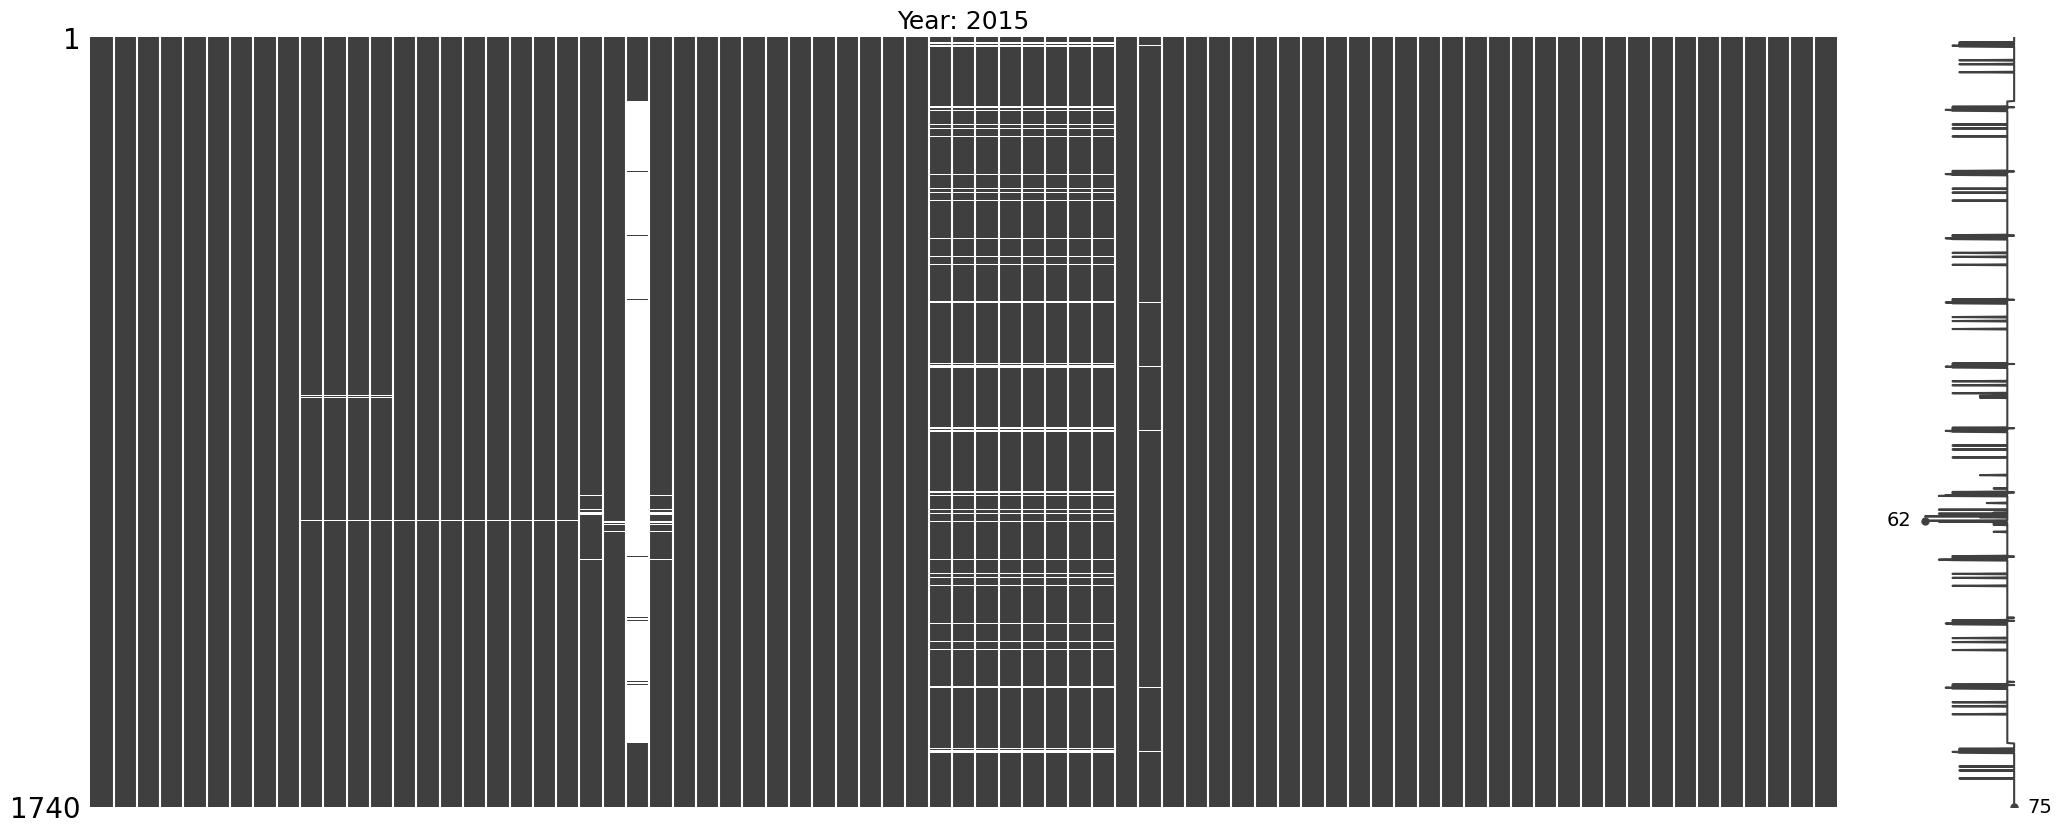

In [375]:
msno.matrix(dataset, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {dataset.year.iloc[0]}", fontsize=18)

In [376]:
dataset

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,rainfall_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2015-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2015,1,0.160002,-0.120537,-0.342115,0.120537,0.164934,-0.117264,-0.346438,0.117264,0.008212,0.013665,0.015085,0.013665,35.562516,16.757355,0.000000,26.159935,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2014,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,12.742000,43.686000,0.000000,0.000000,29.708333,22.250000,55.625000,280.792979,52.0,12.0,40.0,30.500000,30.500000,33.500000,27.500000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
1,2015-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2015,1,0.180811,-0.103038,-0.337729,0.103038,0.180456,-0.102711,-0.336806,0.102711,0.010560,0.011225,0.011200,0.011225,35.182870,17.700885,0.000000,26.441878,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,2014,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,13.344359,43.412051,0.000000,0.000000,29.166667,21.166667,55.701754,343.996124,51.0,13.0,38.0,27.166667,31.000000,33.666667,25.833333,1.0,1.0,0.0,26.646936,1.0,0.0,0.0,0.0
2,2015-01,nord,benoue,bibemi,bide,13.972945,9.422292,2015,1,0.172986,-0.089423,-0.323776,0.089423,0.177404,-0.085450,-0.325494,0.085450,0.008799,0.009392,0.009824,0.009392,35.349226,17.832065,0.000000,26.590645,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,2014,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,13.283333,43.788667,0.000000,0.000000,29.833333,21.833333,57.456140,323.569111,51.0,13.0,38.0,31.333333,31.333333,34.000000,27.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
3,2015-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2015,1,0.178563,-0.067295,-0.292543,0.067295,0.180811,-0.066269,-0.294958,0.066269,0.012477,0.018840,0.018732,0.018840,33.780850,16.095806,0.000000,24.938328,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,2014,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,12.311818,41.768182,0.000000,0.000000,29.500000,21.000000,53.846154,325.436769,51.0,12.0,39.0,29.666667,29.666667,33.833333,26.333333,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
4,2015-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2015,1,0.181085,-0.013806,-0.254480,0.013806,0.183872,-0.008080,-0.256086,0.008080,0.023456,0.022051,0.047988,0.022051,34.226989,18.423548,0.000000,26.325269,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,2014,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,12.650000,42.270000,0.000000,0.000000,30.208333,21.083333,55.482456,339.423531,50.0,12.0,38.0,30.833333,30.833333,33.833333,26.833333,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

In [377]:
dataset[dataset.select_dtypes(include='float').columns] = dataset.select_dtypes(include='float').round(6)

rainfall_cols = [col for col in dataset.columns if 'rainfall' in col]
dataset[rainfall_cols] = dataset[rainfall_cols].round(4)

lst_cols = [col for col in dataset.columns if 'lst' in col]
dataset[lst_cols] = dataset[lst_cols].round(2)

bio_cols = [col for col in dataset.columns if 'bio' in col]
dataset[bio_cols] = dataset[bio_cols].round(2)

geo_cols += [f"{col}_std" for col in geo_cols]
dataset[geo_cols] = dataset[geo_cols].round(2)

dataset[mode_cols] = dataset[mode_cols].apply(pd.to_numeric, errors='coerce').astype('Int64')

In [378]:
dataset.shape

(1740, 75)

In [379]:
new_order = ['dt_placement',
             'year',
             'month',
             'year_lc',
             'month_sin',
             'month_cos',
             'GID0',
             'GID1',
             'GID2',
             'GID3',
             'x',
             'y',
             'ndvi',
             'ndmi',
             'ndwi',
             'ndbi',
             'ndvi_mean',
             'ndmi_mean',
             'ndwi_mean',
             'ndbi_mean',
             'ndvi_std',
             'ndmi_std',
             'ndwi_std',
             'ndbi_std',
             'lst',
             'lst_day',
             'lst_night',
             'monthly_lst_min',
             'monthly_lst_max',
             'rainfall',
             'rainfall_acc',
             'monthly_rainfall_acc',
             'distance_to_coast', 
             'distance_to_river', 
             'slope_mean_1km',
             'aspect_mean_200m', 
             'elevation_mean_1km', 
             'hillshade_mean_1km',
             'fs_area_1km', 
             'flow_accu_200m', 
             'distance_to_coast_std',
             'distance_to_river_std', 
             'slope_mean_1km_std', 
             'aspect_mean_200m_std',
             'elevation_mean_1km_std', 
             'hillshade_mean_1km_std', 
             'fs_area_1km_std',
             'flow_accu_200m_std', 
             'lc_prop1', 
             'lc_prop2', 
             'lc_prop3', 
             'lc_type1',
             'lc_type2', 
             'lc_type3', 
             'lc_type4', 
             'lc_type5',
             'bio1',
             'bio2',
             'bio3',
             'bio4',
             'bio5',
             'bio6',
             'bio7',
             'bio8',
             'bio9',
             'bio10',
             'bio11',
             'bio12',
             'bio13',
             'bio14',
             'bio15',
             'bio16',
             'bio17',
             'bio18',
             'bio19']

In [380]:
dataset = dataset[new_order]

In [381]:
dataset.head()

,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2015-01,2015,1,2014,0.5,0.866,nord,benoue,bibemi,adoumri,13.770202,9.240232,0.160002,-0.120537,-0.342115,0.120537,0.164934,-0.117264,-0.346438,0.117264,0.008212,0.013665,0.015085,0.013665,26.16,35.56,16.76,12.74,43.69,0.0,0.0,0.0,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31,36,30,12,12,3,5,8,29.71,22.25,55.62,280.79,52.0,12.0,40.0,30.50,30.50,33.50,27.50,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0
1,2015-01,2015,1,2014,0.5,0.866,nord,benoue,bibemi,bibemi,13.949181,9.263633,0.180811,-0.103038,-0.337729,0.103038,0.180456,-0.102711,-0.336806,0.102711,0.010560,0.011225,0.011200,0.011225,26.44,35.18,17.70,13.34,43.41,0.0,0.0,0.0,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31,36,30,12,12,3,5,8,29.17,21.17,55.70,344.00,51.0,13.0,38.0,27.17,31.00,33.67,25.83,1.0,1.0,0.0,26.65,1.0,0.0,0.0,0.0
2,2015-01,2015,1,2014,0.5,0.866,nord,benoue,bibemi,bide,13.972945,9.422292,0.172986,-0.089423,-0.323776,0.089423,0.177404,-0.085450,-0.325494,0.085450,0.008799,0.009392,0.009824,0.009392,26.59,35.35,17.83,13.28,43.79,0.0,0.0,0.0,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31,36,30,12,12,3,5,8,29.83,21.83,57.46,323.57,51.0,13.0,38.0,31.33,31.33,34.00,27.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0
3,2015-01,2015,1,2014,0.5,0.866,nord,benoue,bibemi,dengui,13.642496,9.235656,0.178563,-0.067295,-0.292543,0.067295,0.180811,-0.066269,-0.294958,0.066269,0.012477,0.018840,0.018732,0.018840,24.94,33.78,16.10,12.31,41.77,0.0,0.0,0.0,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31,36,30,12,12,1,6,7,29.50,21.00,53.85,325.44,51.0,12.0,39.0,29.67,29.67,33.83,26.33,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0
4,2015-01,2015,1,2014,0.5,0.866,nord,benoue,bibemi,djaloumi,13.994667,9.585190,0.181085,-0.013806,-0.254480,0.013806,0.183872,-0.008080,-0.256086,0.008080,0.023456,0.022051,0.047988,0.022051,26.33,34.23,18.42,12.65,42.27,0.0,0.0,0.0,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31,36,30,12,12,3,5,8,30.21,21.08,55.48,339.42,50.0,12.0,38.0,30.83,30.83,33.83,26.83,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0


In [382]:
dataset.shape

(1740, 75)

In [383]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1740 entries, 0 to 1739
Data columns (total 75 columns):
 #   Column                  Non-Null Count  Dtype    
---  ------                  --------------  -----    
 0   dt_placement            1740 non-null   period[M]
 1   year                    1740 non-null   int32    
 2   month                   1740 non-null   int32    
 3   year_lc                 1740 non-null   int32    
 4   month_sin               1740 non-null   float64  
 5   month_cos               1740 non-null   float64  
 6   GID0                    1740 non-null   object   
 7   GID1                    1740 non-null   object   
 8   GID2                    1740 non-null   object   
 9   GID3                    1740 non-null   object   
 10  x                       1740 non-null   float64  
 11  y                       1740 non-null   float64  
 12  ndvi                    1734 non-null   float64  
 13  ndmi                    1734 non-null   float64  
 14  ndwi    

In [384]:
dataset.to_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_grouped.csv', index=False, encoding=enc)

In [385]:
#dataset.to_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_08_grouped.csv', index=False, encoding=enc)